# Part A: Building point-based validation metrics

### Import libraries

In [5]:
import xarray as xr
import os
from time import time
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
from pathlib import Path
from scipy import stats
import glob
import HydroErr as he
import pandas as pd
import dask
from functools import partial
import time
import warnings
from dask.array.core import PerformanceWarning
import calendar

### Define constants

In [6]:
OWNER = "FENZ"

SOUTHBRIDGE = {
    'filename': "southbridge_aws.nc",
    'station_id': "02139bfc0beb28e0229b756e",
    'location': { 'lon': 172.25856, 'lat': -43.84945 }
}
GLENTANNER = {
    'filename': "glentanner_aws.nc",
    'station_id': "b1ccc6ead3273d01c94501bd",
    'location': { 'lon': 170.12862, 'lat': -43.91498 }
}
STATIONS = {
    'Southbridge': SOUTHBRIDGE,
    'Glentanner': GLENTANNER,
}

PARAMETERS = ['wind_speed', 'relative_humidity', 'temperature' ]
VARIABLES = ['wind_speed', 'relative_humidity', 'air_temperature' ]

DATE_RANGES = [
  { 'start_date': "2020-01-06", 'end_date': "2020-01-12" },
  { 'start_date': "2019-07-10", 'end_date': "2019-07-16" },
]

AXIS_LABEL_FONT_SIZE = 8
TITLE_FONT_SIZE = 12

## Define some utility functions

`calc_wind_speed` calculates overall wind speed from the North-South and the East-West wind speed values.

In [7]:
def calc_wind_speed(u, v):
  usqr = u ** 2
  vsqr = v ** 2
    
  # Wind speed calculation is the square root of the sum of the squares
  return np.sqrt(usqr + vsqr)

`plot_model_vs_observations` creates a graph of the predicted and observed data for one variable over one time period

In [8]:
def plot_model_vs_observations(model_data, obs_data, key, month, data_type, ax):
    model_data.plot(ax=ax, linestyle="dashed",color="blue",label="Model")
    obs_data.plot(ax=ax, linestyle="dashed",color="orange",label="Observed")
    ax.set_xlabel("Time", fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_ylabel(data_type, fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_title(f"{data_type}, {key}, {month}")
    ax.legend()

`to_nz_time` converts UTC data to NZ timezone

In [9]:
def to_nz_time(ds):
    months = ds['time'].dt.month
    is_summer_time = (months >= 4) & (months <= 9)

    shift_12h = np.timedelta64(12, 'h')
    shift_13h = np.timedelta64(13, 'h')

    nz_offsets = np.where(is_summer_time, shift_12h, shift_13h)

    local_times = ds['time'].values + nz_offsets
    ds = ds.drop_vars('time')
    ds = ds.assign_coords(time=(['time'], local_times))
    
    return ds

## Q1: Loading the data

> For your observational stations you will use two FENZ weather station locations. The data files
> are in the assignment dropbox (glentanner_aws.nc, and southbridge_aws.nc)
> a. Glentanner (a mountainous site in Mackenzie)
> b. Southbridge (a flat terrain site in Canterbury

This code loads the two provided data files into an XArray dataset, and stores it in the STATIONS dictionary, for use by subsequent code cells.

In [10]:
for k_ix, key in enumerate(STATIONS.keys()):
    stn = STATIONS[key]
    file_path = stn["filename"]
    dataset = xr.open_dataset(f'./{file_path}')
    dataset = to_nz_time(dataset)
    stn['dataset'] = dataset

## Q2: Extract time series for January and July

> Use a week of your choice in January and a week in July to extract the time series from a WRF
> grid point and the nearest FENZ weather station.

The function 'extract_model_series' loads a time slice from the WRF data for a given data type (i.e. 'RH' or 'T') for the given lat/lon location.

In [11]:
def extract_model_series(data_type, start_date, end_date, location, height=2):
    date_obj = datetime.strptime(start_date, "%Y-%m-%d")

    # If looking for wind speed data, we need to calculate it from the two directions.    
    if data_type == 'WS':
      west_to_east = xr.open_dataset(f"/mnt/data/MetService_WRF/U_{date_obj.year}{date_obj.month:02d}01000000.nc")
      west_to_east = west_to_east['U'].sel(height=10, lat=location['lat'], lon=location['lon'], method="nearest")        
      south_to_north = xr.open_dataset(f"/mnt/data/MetService_WRF/V_{date_obj.year}{date_obj.month:02d}01000000.nc")
      south_to_north = south_to_north['V'].sel(height=10, lat=location['lat'], lon=location['lon'], method="nearest")
      dataset = calc_wind_speed(west_to_east, south_to_north)
    else:
      dataset = xr.open_dataset(f"/mnt/data/MetService_WRF/{data_type}_{date_obj.year}{date_obj.month:02d}01000000.nc")      
      dataset = dataset[data_type].sel(height=height, lat=location['lat'], lon=location['lon'], method="nearest")

    # Convert times to NZ local time
    dataset = to_nz_time(dataset)

    # Extract the right time slice
    dataset = dataset.sel(time=slice(start_date, end_date))

    # If extracting temperature data, convert it from Kelvin to Celsius
    if data_type == 'T':
        dataset = dataset - 273.15
    return dataset

### Sanity check on time zones

Both data sets are in UTC. To get accurate plots I added the `to_nz_time` utility function above to convert the data to local time. The code below demonstrates by plotting temperature from a dataset in the `STATIONS` dictionary for a 2 day period, to confirm that the peaks are in the afternoons rather than the early hours of the morning.

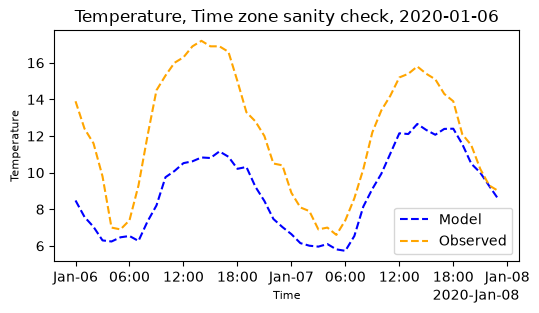

In [12]:
# Sanity check: are both datasets in NZ time zone?
# If they are the the temperatures should peak in the afternoon and drop overnight.
stn = STATIONS['Glentanner']
d = { 'start_date': "2020-01-06", 'end_date': "2020-01-07" }
obs = np.squeeze(stn['dataset'].temperature.sel(time=slice(d['start_date'], d['end_date'])))
pred = extract_model_series('T', d['start_date'], d['end_date'], stn['location'])

# Verify visually
fig, ax = plt.subplots(1, 1, figsize=(6,3))
plot_model_vs_observations(pred, obs, 'Time zone sanity check', d["start_date"], 'Temperature', ax)
plt.show()


## Q3: Calculate RMSE, R squared, and IoA

As instructed in the assignment reading, the code below makes use of the HydroErr package for calculation of metrics, and Pandas to create a DataFrame for conveniently displaying the data in a table.


`get_observations_and_predictions` selects the model and observed values for a particular weather station and a particular date range.

In [13]:
def get_observations_and_predictions(obs_key, pred_key, stn, dr):
  obs = np.squeeze(stn['dataset'][obs_key].sel(time=slice(dr['start_date'], dr['end_date'])))
  pred = extract_model_series(pred_key, dr['start_date'], dr['end_date'], stn['location'])
  assert len(obs) == len(pred)
  return obs, pred

This code loops over the selected weather stations, loads model and observed data for the January and July date ranges, calculates the metrics, and stores them in an array that is then presented in a table.

In [14]:
# Accumulators for the three variables
rh = []
t = []
ws = []

d1 = DATE_RANGES[0]
d2 = DATE_RANGES[1]

def build_row(key, variable, obs1, pred1, obs2, pred2):
  row = {
      'Location': key,
      'Variable': variable,
      'RMSE Jan': he.HydroErr.rmse(pred1.values, obs1.values),
      'IOA Jan': he.HydroErr.d(pred1.values, obs1.values),
      'R SQUARED Jan': he.HydroErr.r_squared(pred1.values, obs1.values),
      'RMSE Jul': he.HydroErr.rmse(pred2.values, obs2.values),
      'IOA Jul': he.HydroErr.d(pred2.values, obs2.values),
      'R SQUARED Jul': he.HydroErr.r_squared(pred2.values, obs2.values),
  }
  return row

# For each location
for k_ix, key in enumerate(STATIONS.keys()):
  stn = STATIONS[key]

  # Create a temperature row
  t_obs1, t_pred1 = get_observations_and_predictions('temperature', 'T', stn, d1)
  t_obs2, t_pred2 = get_observations_and_predictions('temperature', 'T', stn, d2)
  t_row = build_row(key, 'T', t_obs1, t_pred1, t_obs2, t_pred2)
  t.append(t_row)

  # Create a relative humidity row
  rh_obs1, rh_pred1 = get_observations_and_predictions('relative_humidity', 'RH', stn, d1)
  rh_obs2, rh_pred2 = get_observations_and_predictions('relative_humidity', 'RH', stn, d2)
  rh_row = build_row(key, 'RH', rh_obs1, rh_pred1, rh_obs2, rh_pred2)
  rh.append(rh_row)

  # Create a wind speed row
  ws_obs1, ws_pred1 = get_observations_and_predictions('wind_speed', 'WS', stn, d1)
  ws_obs2, ws_pred2 = get_observations_and_predictions('wind_speed', 'WS', stn, d2)
  ws_row = build_row(key, 'WS', ws_obs1, ws_pred1, ws_obs2, ws_pred2)
  ws.append(ws_row)

statistics = pd.DataFrame(t + rh + ws)
statistics

,Location,Variable,RMSE Jan,IOA Jan,R SQUARED Jan,RMSE Jul,IOA Jul,R SQUARED Jul
0,Southbridge,T,2.543971,0.930070,0.809305,2.155090,0.901507,0.685838
1,Glentanner,T,3.503258,0.779664,0.606544,2.212541,0.764893,0.428470
2,Southbridge,RH,18.176009,0.753635,0.625788,9.993523,0.749596,0.377793
3,Glentanner,RH,19.490305,0.614249,0.146261,14.770370,0.614602,0.273786
4,Southbridge,WS,2.207541,0.738001,0.384923,1.672844,0.726383,0.308287
5,Glentanner,WS,2.843924,0.764872,0.365526,2.210997,0.606283,0.138195


 ## Q4: Visualise the data

> Produce time series plots of observed and modelled meteorological variables at both
> locations. Your plots should demonstrate a one to one comparison and their objective is to
> visualize the trend and biases while investigating the actual data without summary error
> statistics yet. Describe and discuss your results.

`plot_model_vs_observations` creates a plot of the model and observed data for one variable in one date range.

In [15]:
def plot_model_vs_observations(model_data, obs_data, key, month, data_type, ax):
    model_data.plot(ax=ax, linestyle="dashed",color="blue",label="Model")
    obs_data.plot(ax=ax, linestyle="dashed",color="orange",label="Observed")
    ax.set_xlabel("Time", fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_ylabel(data_type, fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_title(f"{data_type}, {key}, {month}")
    ax.legend()
    

Generate the comparison plots. Chosen weeks are the week starting __Jan 6th 2020__, and the week starting __July 10th 2019__.

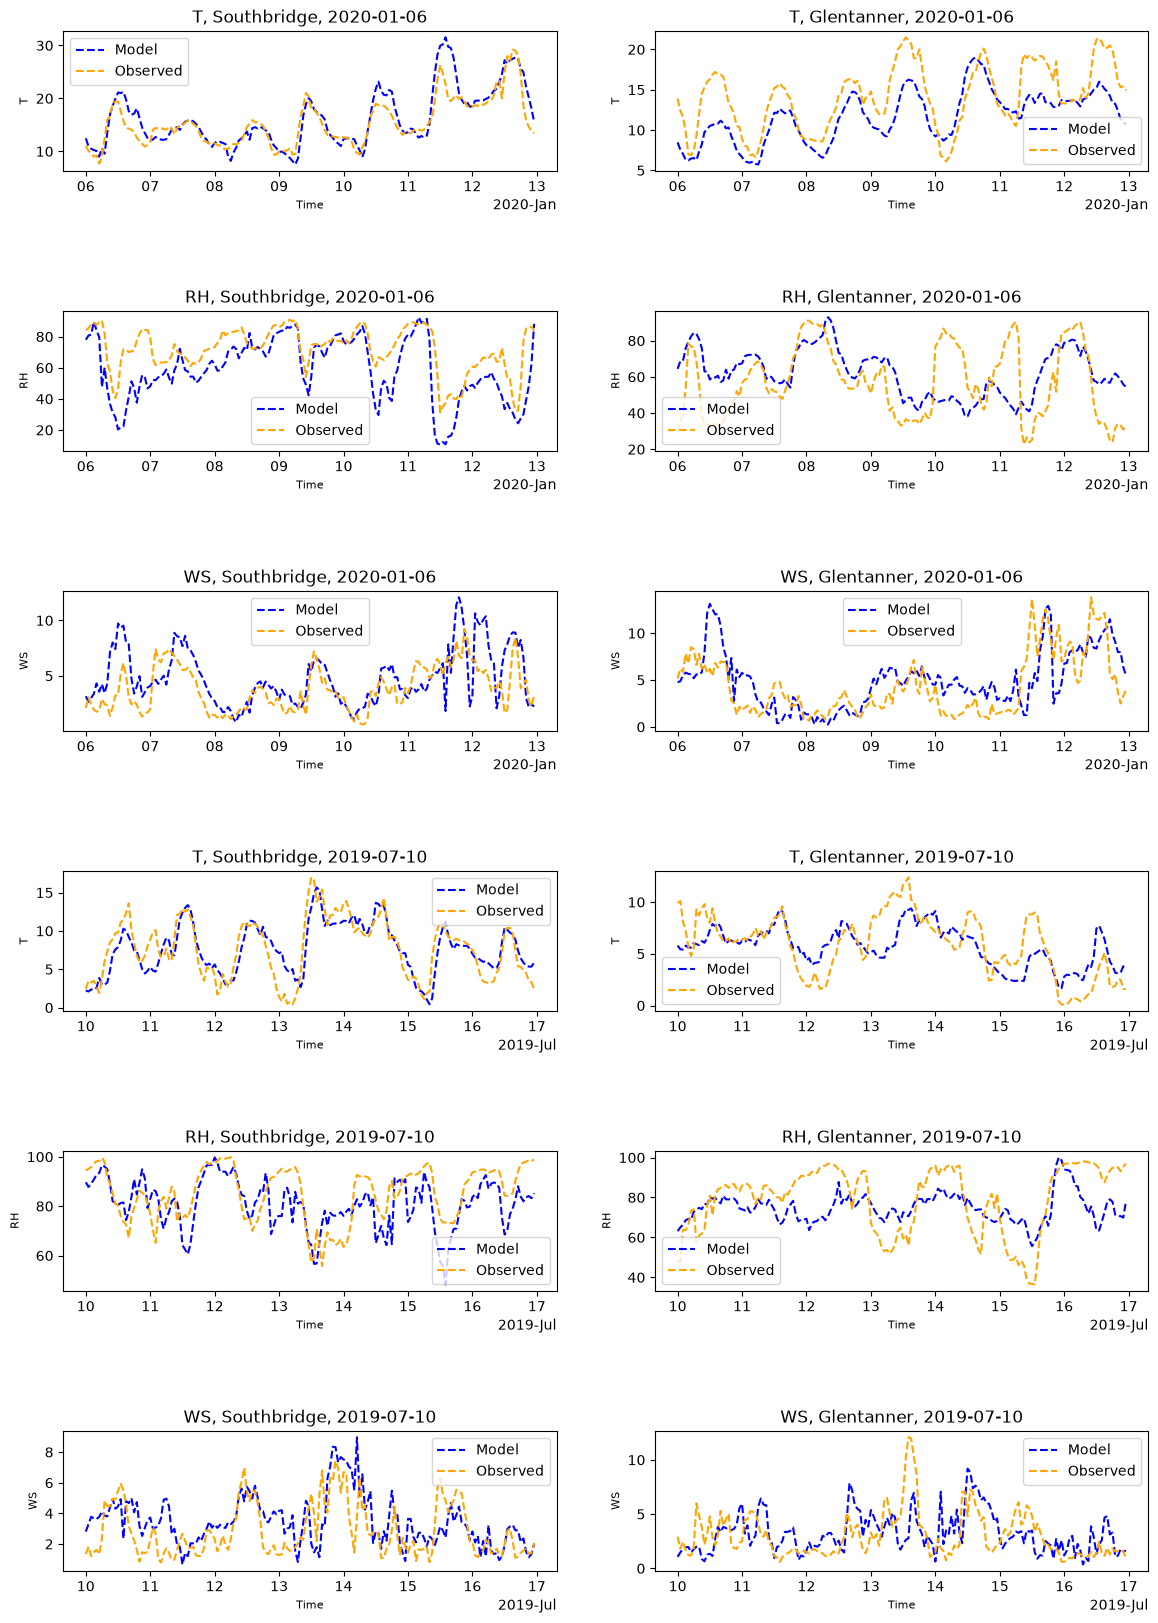

In [16]:
fig, axs = plt.subplots(6, 2, figsize=(14,20))

ax_y = 0
for d_ix, date_range in enumerate(DATE_RANGES):
    start_date = date_range['start_date']
    end_date = date_range['end_date']

    ax_y = d_ix * 3
    
    for k_ix, key in enumerate(STATIONS.keys()):
      stn = STATIONS[key]
      dataset_observations = stn['dataset']
      time_slice_observed = dataset_observations.sel(time=slice(start_date, end_date))

      t_obs, t_model = get_observations_and_predictions('temperature', 'T', stn, date_range)
      plot_model_vs_observations(t_model, t_obs, key, start_date, 'T', axs[ax_y+0][k_ix])
        
      rh_obs, rh_model = get_observations_and_predictions('relative_humidity', 'RH', stn, date_range)
      plot_model_vs_observations(rh_model, rh_obs, key, start_date, 'RH', axs[ax_y+1][k_ix])   
    
      ws_obs, ws_model = get_observations_and_predictions('wind_speed', 'WS', stn, date_range)     
      plot_model_vs_observations(ws_model, ws_obs, key, start_date, 'WS', axs[ax_y+2][k_ix])

plt.subplots_adjust(hspace=1.0)
plt.show()

## Discussion of the graphs & metrics

### Southbridge: Graphs

Southbridge lies on flat terrain in mid-Canterbury. In all the plots above (left column) you can see a fairly strong agreement between the predictions and observations. This is particularly true for temperature data, where the peaks & troughs are well predicted for the diurnal temperature pattern. Relative humidity in January was quite consistently underestimated by the WRF model - the overall shape of the graph is fairly well aligned but with a negative bias. Wind speed forecast in January has an interesting lag at the start of the time period, as if the forecast wind arrived later than expected, and in July does a fairly good job of prediction but doesn't capture the gustiness. There was a high wind event from July 13th to 14th 2019, and the model does show predicted higher winds but not the jagged peaks & troughs seen in the observations.

### Southbridge: Metrics

Temperature metrics for Southbridge also reflect the effectiveness of the WRF model for this area. The RMSE is quite low at 2-2.5 degrees, IoA is over 0.9 for both periods, and R$^2$ fairly high at 0.8 and 0.68. The lower R$^2$ value for July tracks with the July graph where it can be seen that the observations have slightly more variation than the predictions - for example the temperature rose more than predicted between the 10th & 11th and dropped more than predicted on the 13th. The model predicted the increases and decreases, but underestimated their magnitude.

The noted negative bias for relative humidity in January is reflected by the 18% RMSE for that period, compared to 9% in July. But the R$^2$ and IoA remain high in January, because the overall shape of the prediction is close to the real world diurnal pattern: this is confirmed visually in that the observed and predicted lines on the graph overall track the same shapes. In July the RMSE is lower, showing less of a consistent bias, but the R$^2$ is much lower. A few big differences visible on the graph (between 11th & 12th, and between 15th & 16th) are probably the differences that skewed the R$^2$ value so heavily.

Wind speed in Southbridge has a low RMSE and high IoA but the R$^2$ values are very low for both periods. I think this is to be expected since wind speed is much less predictable then temperature and humidity, which tend to strongly follow diurnal patterns. The high IoA for wind speed indicates that the model was predicting that it will be very windy, but the low R$^2$ shows that the model can't tell exactly _when_ it will be windy, or when the periods of strongest gusts will occur.

### Glentanner: Graphs

Glentanner is located in a deep valley in a mountainous area, so I expect less accurate results from the WRF model. The graphs (in the right column) support this - while they often have a rough visual correlation there is much more difference than is seen for Southbridge. In January the model seems to have a fairly consistent cold bias, and in July its temperature predictions are a lot less variable than what was observed. Humidity in both months has a much flatter prediction, while the observations were a lot more variable. Wind speed predictions are similar to those in Southbridge in that the prediction captured the fact that there would be wind, but not the magnitude or timing of the strongest gusts.

### Glentanner: Metrics

Temperature is less well predicted in Glentanner than in Southbridge, as is shown in the lower values of all metrics for both periods. In January there was a fairly consistent cold bias that is reflected in a higher RMSE at 3.5 degrees. In winter the model tends to predict a flatter line while in reality the temperature is a lot more variable. This is reflected in the much lower R$^2$ value in July.

Relative humidity has a high RMSE and low R$^2$ in both time periods. The graph supports this in that the predicted lines are a lot flatter than the observations - the R$^2$ value is picking up on large variances between model and observation.

The same July 2019 high wind event noted in Southbridge was also observed in Glentanner, and again the model predicted the existence of hight winds but not their magnitude. The R$^2$ value for wind speed in July in Glentanner was just 0.14 - R$^2$ is very sensitive to outliers so a couple of extremely gusty periods in that week caused this very low value. Despite this the IoA remains fairly consistent between the two weeks because the rest of those weeks were fairly well predicted.


## Q5: Scatter plots

> Produce scatter plots of observed and modelled meteorological variables for both locations.
> Add a linear trend line that best fits the data points and report the equation of the line. For
> reference this is similar to the green lines in the case studies presented in the reading material
> handout. Describe and discuss your results.

`scatter_plot` creates one plot for given observations and predictions for one variable in a particular date range.

In [17]:
def scatter_plot(ax, observations, predictions, start_date, location, variable, variable_stats):
    slope, intercept, rvalue, pvalue, stderr = stats.linregress(observations.values, predictions.values)
    regression_line = slope * t_obs + intercept

    ax = axs[k_ix][d_ix]

    ax.scatter(observations.values, t_pred.values)
    ax.plot(observations, observations, color='red', linestyle='--',  label=f'1:1 line')
    ax.plot(observations, regression_line, color='green', label=f'Fit: P = {intercept:.2f} + {slope:.2f}*O')
    ax.grid(True, linestyle='--')
    ax.set_title(f'{location} {variable} week of {start_date}', loc='left', pad=25)
    
    # Add subtitle with R2, RMSE, IoA, and Bias
    location_stats = variable_stats.loc[variable_stats['Location'] == key]
    stat_col = 'Jan' if d_ix == 0 else 'Jul'
    rmse = location_stats[f'RMSE {stat_col}'].item()
    r2 = location_stats[f'R SQUARED {stat_col}'].item()
    ioa = location_stats[f'IOA {stat_col}'].item()
    mean_bias = (t_pred - t_obs).mean()
      
    ax.text(0.0, 1.02, f'R2={r2:.2f} RMSE={rmse:.2f} IOA={ioa:.2f} Bias={mean_bias:.2f}', transform=ax.transAxes, fontsize=8, color='gray')
    ax.legend(loc='upper left')
    ax.set_xlabel('Observed')
    ax.set_ylabel('Modelled')

### 5a: Temperature

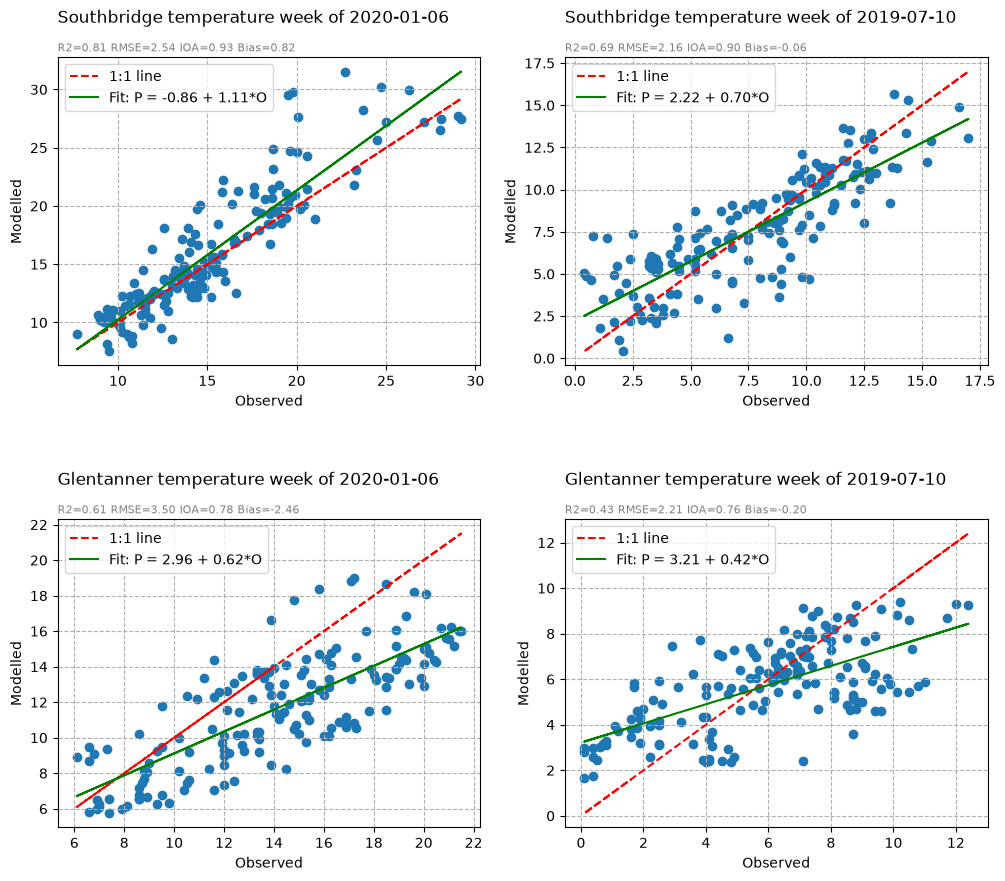

In [18]:
# Loop over stations and then date ranges to create one scatter plot per date range for temperature
fig, axs = plt.subplots(2, 2, figsize=(12,10))
temp_rows = statistics.loc[statistics['Variable'] == 'T']

for k_ix, key in enumerate(STATIONS.keys()):
  stn = STATIONS[key]
  d_ix = 0

  for d_ix, d in enumerate(DATE_RANGES):
    t_obs, t_pred = get_observations_and_predictions('temperature', 'T', stn, d)
    ax = axs[k_ix][d_ix]
    scatter_plot(ax, t_obs, t_pred, d['start_date'], key, 'temperature', temp_rows)
      
plt.subplots_adjust(hspace=0.5)
plt.show()

### 5b: Relative humidity

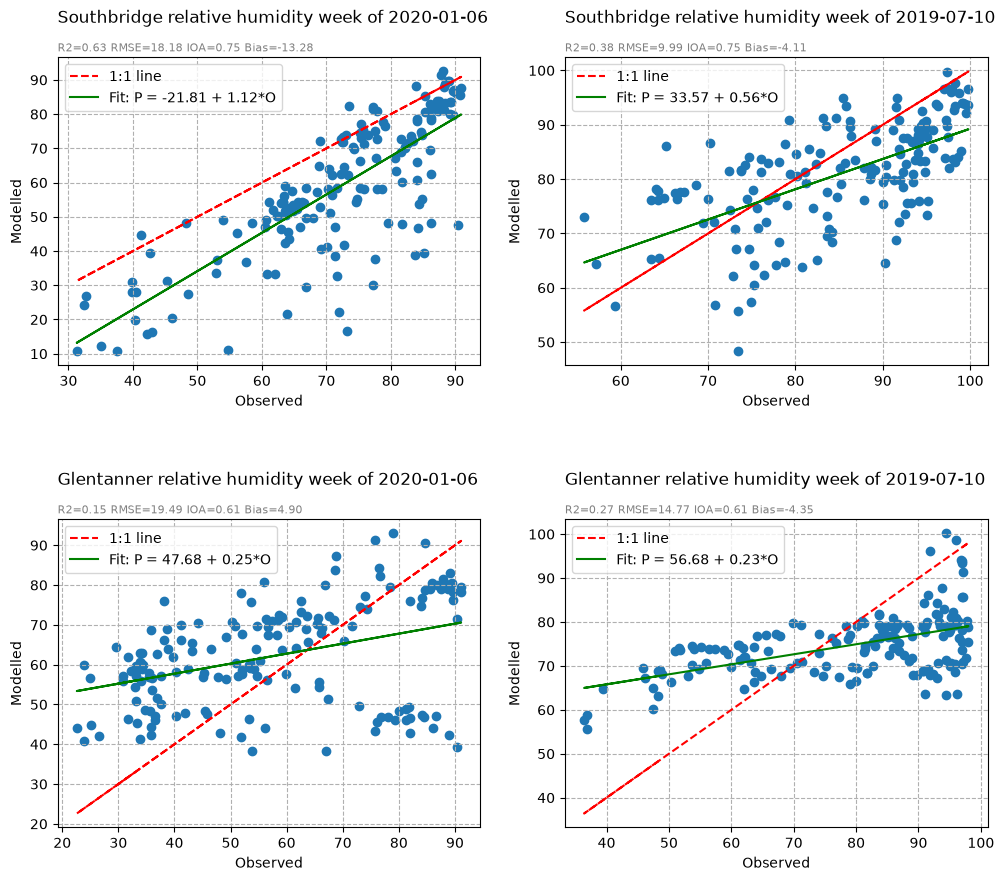

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(12,10))
stat_rows = statistics.loc[statistics['Variable'] == 'RH']

for k_ix, key in enumerate(STATIONS.keys()):
  stn = STATIONS[key]
  d_ix = 0

  for d_ix, d in enumerate(DATE_RANGES):
    t_obs, t_pred = get_observations_and_predictions('relative_humidity', 'RH', stn, d)
    ax = axs[k_ix][d_ix]
    scatter_plot(ax, t_obs, t_pred, d['start_date'], key, 'relative humidity', stat_rows)
      
plt.subplots_adjust(hspace=0.5)
plt.show()

### 5c: Wind speed

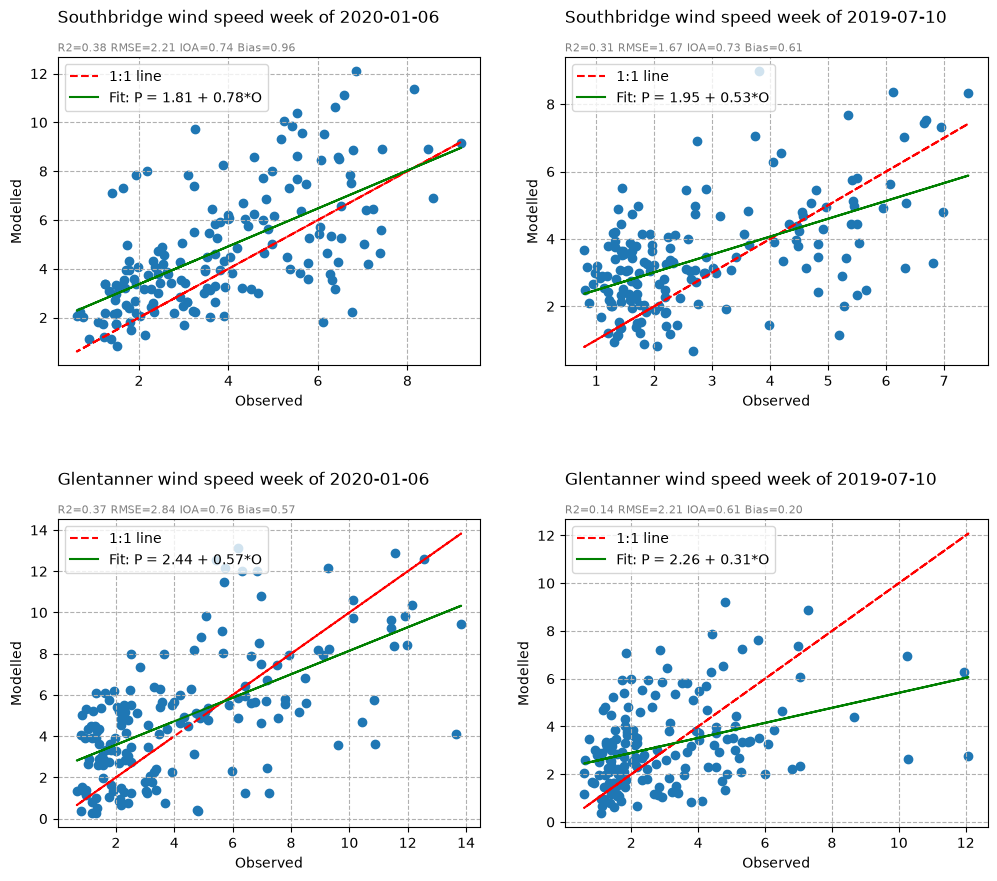

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(12,10))
stat_rows = statistics.loc[statistics['Variable'] == 'WS']

for k_ix, key in enumerate(STATIONS.keys()):
  stn = STATIONS[key]
  d_ix = 0

  for d_ix, d in enumerate(DATE_RANGES):
    t_obs, t_pred = get_observations_and_predictions('wind_speed', 'WS', stn, d)
    ax = axs[k_ix][d_ix]
    scatter_plot(ax, t_obs, t_pred, d['start_date'], key, 'wind speed', stat_rows)

plt.subplots_adjust(hspace=0.5)
plt.show()

### Scatter plots discussion

#### Overview

By scanning the scatter plots it is obvious that the flat location of Southbridge creates better WRF model predictions than the mountainous location of Glentanner. The points on the plots are consistently more tightly grouped for Southbridge than for Glentanner, and the fit lines are closer to the ideal 1:1 lines.

Comparing the three variables shows that temperature is the most accurately predicted. In both locations the points are most tightly clustered for temperature, slightly less so for relative humidity, and most loosely clustered for wind speed.

#### Temperature

The best model performance overall was for temperature prediction in Southbridge. This fits with the highest IoA score of any of the variables and time period (0.93 for Southbridge temperature in January). The regression line fits very closely with the ideal 1:1 line.

Glentanner's temperature predictions show the summer cold bias. WRF models take an average elevation over each grid cell, and because Glentanner lies at the bottom of a deep valley its average elevation is higher than its actual elevation, so the model predicts a colder temperature.

#### Relative humidity

In Southbridge the scatter plot visualises the summertime dry bias ver clearly, but the slope of the regression line is very close to the ideal 1:1 line - showing that the model is predicting the daily rise and fall of humidity very well, but with a constant offset towards assuming it is drier than it is. For winter this bias improves significantly.

Relative humidity prediction in Glentanner is poor in both time periods, as is demonstrated on the plots by very flat regression lines and in the statistics by low values across the metrics.

#### Wind speed

The winter storm impact in July 2019 is visible in quite flat regression lines for both locations. Glentanner also shows some very distant outliers that represent where the model's data points missed the magnitude of the wind speed changes.

In all four wind speed plots, the data points are very loosely clustered, showing that wind speed is the hardest variable to accurately predict, especially in mountainous terrain.

# Part B

### 1. Selected locations


|Island|Region|Location|Elevation Category|Approximate elevation|Latitude|Longitude|
|---|---|---|---|---|---|---|
|North Island|Waikato|Port Taharoa AWS|Coastal Low|25m|-38.166|174.705|
|North Island|Waikato|Paeroa AWS|Inland Low|18m|-37.371|175.684|
|North Island|Waikato|Rotorua Airport|High|285m|-38.106|176.315|
|North Island|Manawatū-Whanganui|Wanganui Airport|Coastal Low|8m|-39.961°|175.026°|
|North Island|Manawatū-Whanganui|Ohakea AWS|Inland Low|50m|-40.196°|175.381|
|North Island|Manawatū-Whanganui|Waiouru Aero|High|819.0|-39.446|175.658|
|South Island|Canterbury|New Brigton Pr|Coastal Low|8m|-43.506°|172.734°|
|South Island|Canterbury|Timaru Airport|Inland Low|27m|-44.305°|171.221°|
|South Island|Canterbury|Sugar Loaf AWS|High|496.0|-43.604|172.649|
|South Island|Otago|Nugget Point AWS|Coastal Low|131m|-46.448°|169.812°|
|South Island|Otago|Roxburgh WXT AWS|Inland Low|154m|-45.517°|169.313°|
|South Island|Otago|Swampy Summit AWS|High|716.0|-45.801|170.477|

#### Notes

There was a lack of high altitude locations in the North Island, so Rotorua Airport is counted as 'high' - despite being only 285m ASL it is considerably higher than the other two points in the Waikato.

On the other hand Otago had a lack of low altitude locations, even at the coast, but the coastal and inland locations are considerably lower than the selected high altitude location.

## 2. Loading and grouping data

The next cell contains constants for the selected locations and the time frame.

In [21]:
LOCATIONS = {
    # Waikato
    'Port Taharoa AWS': {'lat': -38.166, 'lon': 174.705},
    'Paeroa AWS': {'lat': -37.371, 'lon': 175.684},
    'Rotorua Aero AWS': {'lat': -38.106, 'lon': 176.315},
    # Manawatu
    'Wanganui Aero AWS': {'lat': -39.961, 'lon': 175.026},
    'Ohakea AWS': {'lat': -40.196, 'lon': 175.381},
    'Waiouru Aero': {'lat': -39.446, 'lon': 175.658},
    # Canterbury
    'New Brighton Pr WXT': {'lat': -43.506, 'lon': 172.734},
    'Timaru Airport AWS': {'lat': -44.305, 'lon': 171.221},
    'Sugar Loaf AWS': {'lat': -43.604, 'lon': 172.649},
    # Otago
    'Nugget Point AWS': {'lat': -46.448, 'lon': 169.812},
    'Roxburgh WXT AWS': {'lat': -45.517, 'lon': 169.313},
    'Swampy Summit AWS': {'lat': -45.801, 'lon': 170.477}
}

LOCATION_NAMES = list(LOCATIONS.keys())

# These dates are the full 5 year range used for the .sel() calls
START_DATE = f'2013-01-01'
END_DATE = f'2017-12-31'

# These are the lat & lon values for the selected locations
lats_to_select = [ loc['lat'] for loc in LOCATIONS.values() ]
lons_to_select = [ loc['lon'] for loc in LOCATIONS.values() ]
location_names = list(LOCATIONS.keys())

# We save thse into data arrays for use in the file loading
lat_da = xr.DataArray(lats_to_select, dims='points')
lon_da = xr.DataArray(lons_to_select, dims='points')

### Load model data

#### Note: only 4 years of model data has been evaluated, not 5

I have found it extremely challenging trying to load the required 5 years of data from the WRF files. My initial strategy was to load all 60 files for one variable with `open_mfdataset`, then select out the 12 locations, and treat that as the source dataset. But at some point that dataset needs to be materalised for plotting (or for writing to a NetCDF file, as I was trying to do to avoid re-loading repeatedly), and this process would either crash the notebook or take longer than my session on the Sky server was willing to last.

The code above uses a different strategy. For a given time period (I have been running for 12 months at a time), it opens a group of files with `open_mfdataset` but uses a preprocessing function to do the location selection. I then save the resulting 12-month dataset to a file to be used later. These files will be submitted alongside the notebook, and if you're going to re-run the notebook for marking then they will need to be placed in the same directory as the notebook.

I tried to make the below functions as performant as possible but still find that it can take as long as two minutes to materialise data for just one of the monthly WRF files (based on the `print` statement just after the `.load()` call in `mod_preprocess`). Attempting to load more than 12 months at once typically crashes the notebook.

In [22]:
# There are some duplicate timestamps in the files due to the daylight saving rollover,
# this gets rid of them before they can cause problems
def de_dupe_times(dataset):
    times = dataset['time'].values
    _, unique_ix = np.unique(times, return_index=True)
    return dataset.isel(time=unique_ix)

# Pre-processing for the model data:
#  - select for the given variable at the selected locations
def mod_preprocess(ds, lats, lons, location_names, var_name="T"):
    t0 = time.time()
    loc_data = ds[var_name].load()
    t1 = time.time()
    # print(f"Took {t1-t0:.2f}s to load one file")
    loc_data = loc_data.sel(lat=lats, lon=lons, method="nearest").drop_duplicates(dim='time')
    loc_data = de_dupe_times(loc_data)
    loc_data = loc_data.assign_coords(location=('points', location_names))
    loc_data = loc_data.swap_dims({'points': 'location'})
    return loc_data

# Creates a combined dataset for the model data, by pulling data from all the
# WRF files for the whole date range, and then selecting out the data just
# for the 12 locations.
def get_combined_model_data(variable, start_year, end_year):
    start_file = f"{variable}_{start_year}0101000000.nc"
    end_file = f"{variable}_{end_year}1201000000.nc"
    all_files = sorted(glob.glob(f"/mnt/data/MetService_WRF/{variable}_*.nc"))
    file_list = [
        f for f in all_files if start_file <= f.split("/")[-1] <= end_file
    ]
    # The preprocessing function gets applied while the files are being opened
    # via open_mfdataset.
    preprocess_func = partial(mod_preprocess, lats=lat_da, lons=lon_da, location_names=location_names, var_name=variable)

    big_ds = xr.open_mfdataset(
        file_list,
        preprocess=preprocess_func,  
        concat_dim='time',
        combine='nested',
        coords="minimal",
        compat="override"
    )
    big_ds = big_ds.where(~big_ds['time'].isnull(), drop=True)
    big_ds = big_ds.sortby(['time', 'lat', 'lon'])
    return big_ds 

##### The next three cells demonstrate how I loaded the model data into files.

These were run with the 'YEAR' constant set to 2013, 2014, 2015, then 2016, so I could collect enough files for the next step.

In [23]:
YEAR=2015
t_filename = f't_model_preloaded_{YEAR}.nc'

if (os.path.isfile(t_filename)):
    print('Using existing T file')
    temperature_model = xr.open_dataset(t_filename)
else:
    t_data = get_combined_model_data('T', YEAR, YEAR).sel(height=2)
    # Rename variable 'T' to 'temperature' to match the obervation datasets
    temperature_model = xr.Dataset(data_vars = { 'temperature': t_data }, attrs= t_data.attrs.copy())
    # convert temp to celsius
    temperature_model = temperature_model - 273.15
    # Move to NZ timezone
    temperature_model = to_nz_time(temperature_model)
    temperature_model.to_netcdf(t_filename)


Using existing T file


In [24]:
rh_filename = f'rh_model_preloaded_{YEAR}.nc'

if (os.path.isfile(rh_filename)):
    print('Using existing RH file')
    relative_humidity_model = xr.open_dataset(rh_filename)
else:
    rh_data = get_combined_model_data('RH', YEAR, YEAR).sel(height=2)
    # Rename variable 'RH' to 'relative_humidity' to match the obervation datasets
    relative_humidity_model = xr.Dataset(data_vars = { 'relative_humidity': rh_data }, attrs = rh_data.attrs.copy())
    relative_humidity_model = to_nz_time(relative_humidity_model)
    relative_humidity_model.to_netcdf(rh_filename)

Using existing RH file


In [25]:
ws_filename = f'ws_model_preloaded_{YEAR}.nc'

if (os.path.isfile(ws_filename)):
    print('Using existing WS file')
    wind_speed_model = xr.open_dataset(ws_filename)
else:
    # wind speed needs calculating from the U and V components
    u_model = get_combined_model_data('U', YEAR, YEAR).sel(height=10)
    v_model = get_combined_model_data('V', YEAR, YEAR).sel(height=10)

    wind_speed = calc_wind_speed(u_model, v_model)
    wind_speed_model = xr.Dataset(data_vars = { 'wind_speed': wind_speed }, attrs = u_model.attrs.copy())
    wind_speed_model = to_nz_time(wind_speed_model)
    wind_speed_model.to_netcdf(ws_filename)

Using existing WS file


#### Combine pre-loaded files

The next cell takes the 4 years of model data that I extracted and stored in local files and combines them into one dataset per variable.

__Note__: You will need the 12 submitted NetCDF files to be in the same directory as this notebook for the next step to work.

In [26]:
## Join the individual yearly data files together

t_models = []
rh_models = []
ws_models = []

YEARS = [ 2013, 2014, 2015, 2016 ]
for y in YEARS:
    t_file = f't_model_preloaded_{y}.nc'
    rh_file = f'rh_model_preloaded_{y}.nc'
    ws_file = f'ws_model_preloaded_{y}.nc'
    t_models.append(xr.open_dataset(t_file))
    rh_models.append(xr.open_dataset(rh_file))
    ws_models.append(xr.open_dataset(ws_file))

temperature_model = xr.concat(t_models, dim='time')
relative_humidity_model = xr.concat(rh_models, dim='time')
wind_speed_model = xr.concat(ws_models, dim='time')


### Load observation data

In [27]:
obs_time_slice = slice(START_DATE, END_DATE)

# Preprocessing step for the observation files.
#  - lat & lon are in the dataset attributes, they're not coordinates on each
#  data point, so I assign them as coordinates to make the comparison of datasets
# smoother later on.
def obs_preprocess(ds, variable, location_name):
    lat = float(ds.attrs['latitude'])
    lon = float(ds.attrs['longitude'])
    loc_data = ds.drop_duplicates(dim='time')
    loc_data = loc_data[variable].sel(time=obs_time_slice)
    loc_data = loc_data.assign_coords(lat=lat, lon=lon, location=location_name)
    loc_data = loc_data.expand_dims(['location'])
    return loc_data

# Creates a combined dataset for observation data, 1 variable, across the whole date range
# and all 12 locations.
def get_combined_observation_data(variable):
    datasets = []
    for name in LOCATIONS:
        ds = xr.open_dataset(f'/mnt/data/MetService_AWS/{name}.nc')
        datasets.append(obs_preprocess(ds, variable, name))
    big_ds = xr.concat(datasets, dim='location', join='outer', coords='minimal', compat='override')
    big_ds = big_ds.where(~big_ds['time'].isnull(), drop=True)
    big_ds = big_ds.sortby(['time'])
    return big_ds

Also combining the obervation datasets into one file per variable makes it easier to generate the breakdown data without looping.

In [28]:
# Suppressing some performance warnings - they are very noisy and performance of this part
# hasn't actually given me any trouble!
warnings.simplefilter('ignore', category=PerformanceWarning)

t_obs_data = get_combined_observation_data('temperature')
temperature_obs = xr.Dataset(data_vars = { 'temperature': t_obs_data }, attrs= t_obs_data.attrs.copy())
temperature_obs = to_nz_time(temperature_obs)

rh_obs_data = get_combined_observation_data('relative_humidity')
relative_humidity_obs = xr.Dataset(data_vars = { 'relative_humidity': rh_obs_data }, attrs = rh_obs_data.attrs.copy())
relative_humidity_obs = to_nz_time(relative_humidity_obs)

ws_obs_data = get_combined_observation_data('wind_speed')
wind_speed_obs = xr.Dataset(data_vars = { 'wind_speed': ws_obs_data }, attrs = ws_obs_data.attrs.copy())
wind_speed_obs = to_nz_time(wind_speed_obs)


### Grouping the datasets

This function takes a model and an observation dataset, and a 'groupby' parameter. The datasets are cleaned of duplicate timestamps, aligned with each other, and then both grouped by the same grouping parameter.

In [29]:
def group_datasets(pred_ds, obs_ds, groupby):
    pred_ds = de_dupe_times(pred_ds)
    obs_ds = de_dupe_times(obs_ds)
    pred_ds, obs_ds = xr.align(pred_ds, obs_ds, join="inner")
    pred_grp = pred_ds.groupby(groupby)
    obs_grp = obs_ds.groupby(groupby)
    return pred_grp, obs_grp

### 2a: Box Plots

Produce boxplots of modelled and observed parameters (not the validation metrics). The presentation of the results should allow for a one-to-one comparison of the underlying Gaussian statistics that the boxplot can provide. This is to be done for monthly and diurnal grouped data. Describe and discuss your results.

In [30]:
# This dictionary brings together the model and observed data for the plots
SOURCE_DATA = {
    'temperature': {
        'pred': temperature_model,
        'obs': temperature_obs,
    },
    'relative_humidity': {
        'pred': relative_humidity_model,
        'obs': relative_humidity_obs,
    },
    'wind_speed': {
        'pred': wind_speed_model,
        'obs': wind_speed_obs,
    }
}
VARIABLES = [ 'temperature', 'relative_humidity', 'wind_speed' ]
box_width = 0.3

station_labels = LOCATIONS.keys()

The show_box_plot function creates one box plot for a particular station, variable, and grouping.

In [31]:
def show_box_plot(ax, observations, predictions, variable, grouping, location, x_positions, x_labels):    
    obs_positions = x_positions - (box_width/2)
    mod_positions = x_positions + (box_width/2)
    obs_boxes = ax.boxplot(observations,
                           positions=list(obs_positions),
                           widths=box_width,
                           patch_artist=True,
                           boxprops=dict(facecolor='lightblue'),
                           medianprops=dict(color='darkturquoise', linewidth=2.5),
                           flierprops=dict(markerfacecolor='darkturquoise')
                          )
    mod_boxes = ax.boxplot(predictions,
                           positions=list(mod_positions),
                           widths=box_width,
                           patch_artist=True,
                           boxprops=dict(facecolor='salmon'),
                           medianprops=dict(color='indianred', linewidth=2.5),
                           flierprops=dict(markerfacecolor='indianred')
                          )

    pred_means, = ax.plot(x_positions, [np.mean(x) for x in predictions], color='salmon', linewidth=2, zorder=1, label='Predicted means')
    obs_means, = ax.plot(x_positions, [np.mean(x) for x in observations], color='lightblue', linewidth=2, zorder=1, label='Observed means')
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_ylabel(variable)
    ax.set_title(f'Observed vs predicted {variable}-{location}')
    ax.legend([obs_boxes['boxes'][0], obs_means, mod_boxes['boxes'][0], pred_means], ['Observed', 'Observed means', 'Predicted', 'Predicted means'])

#### Monthly plots

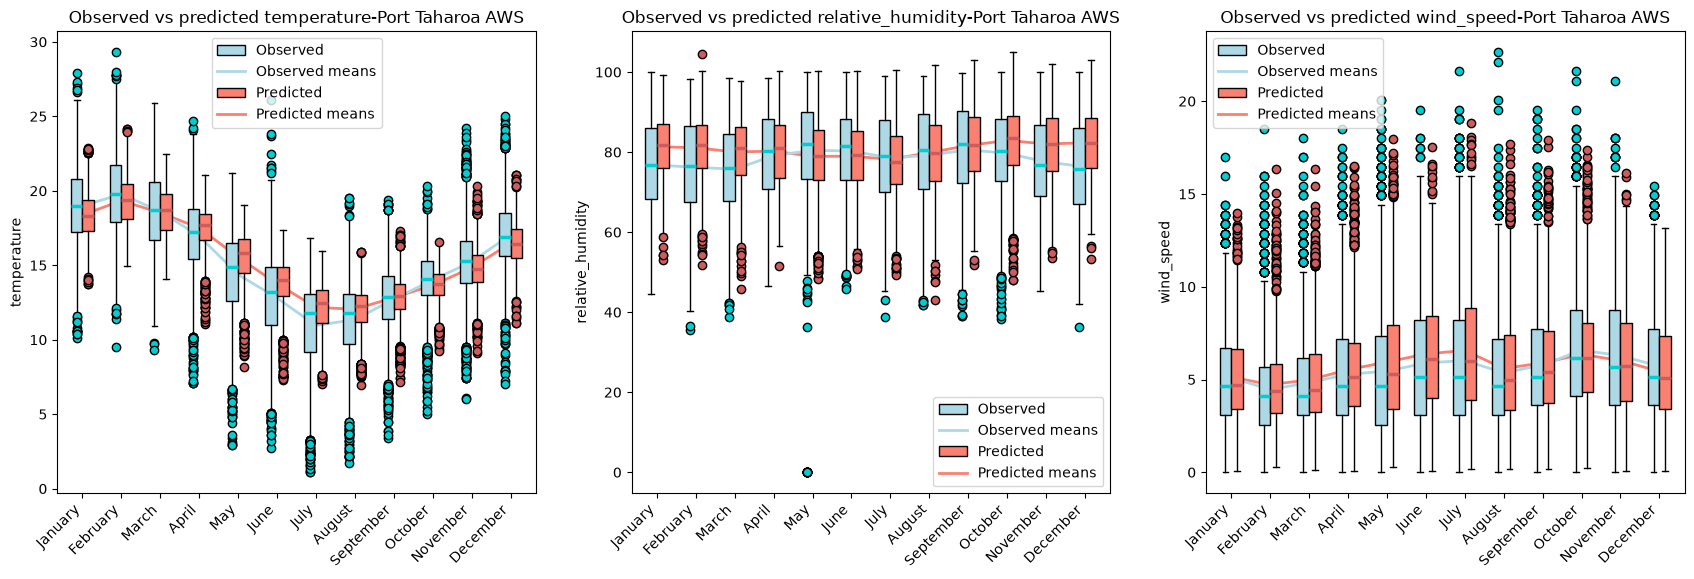

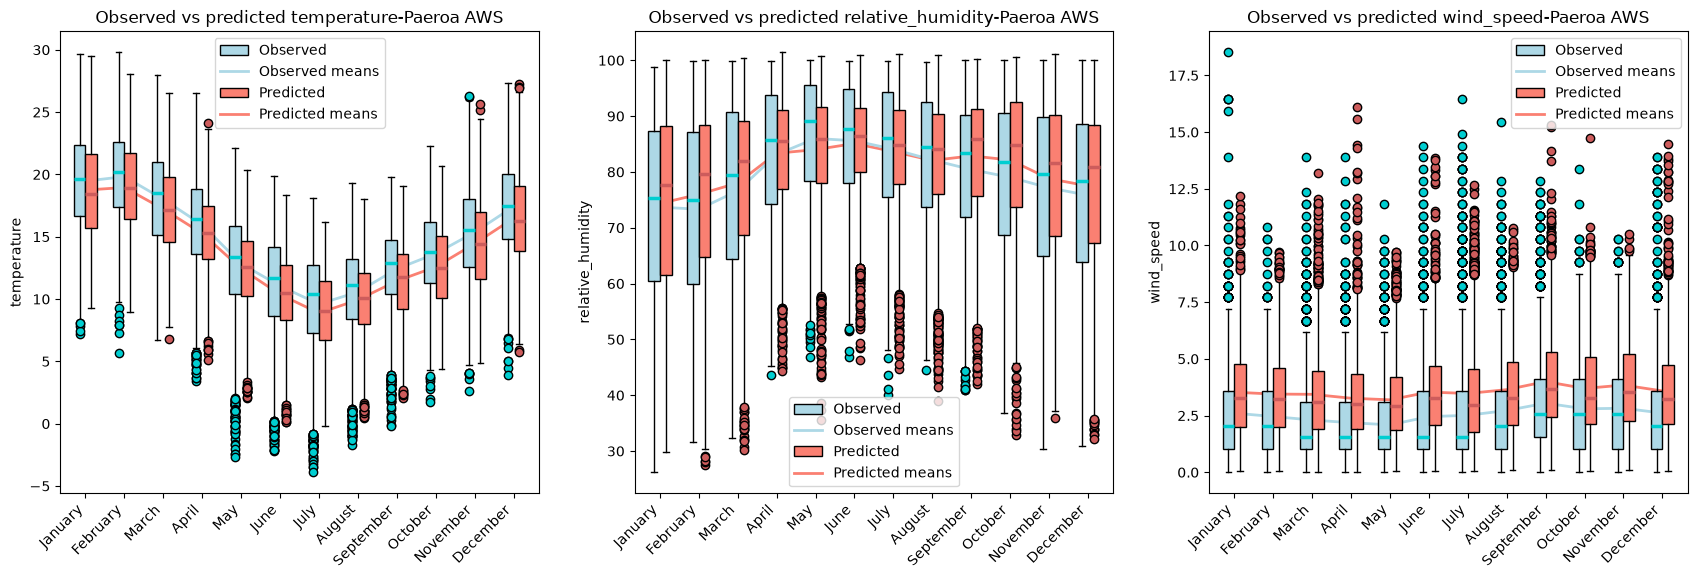

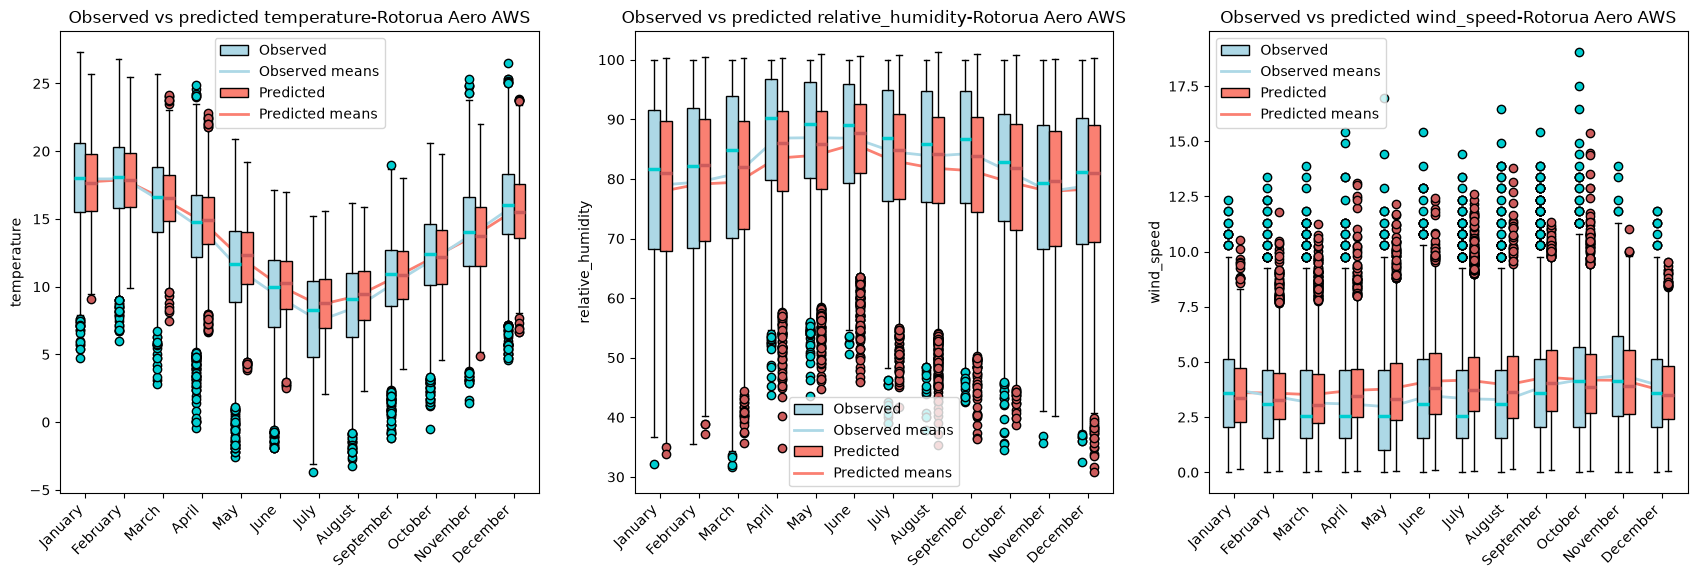

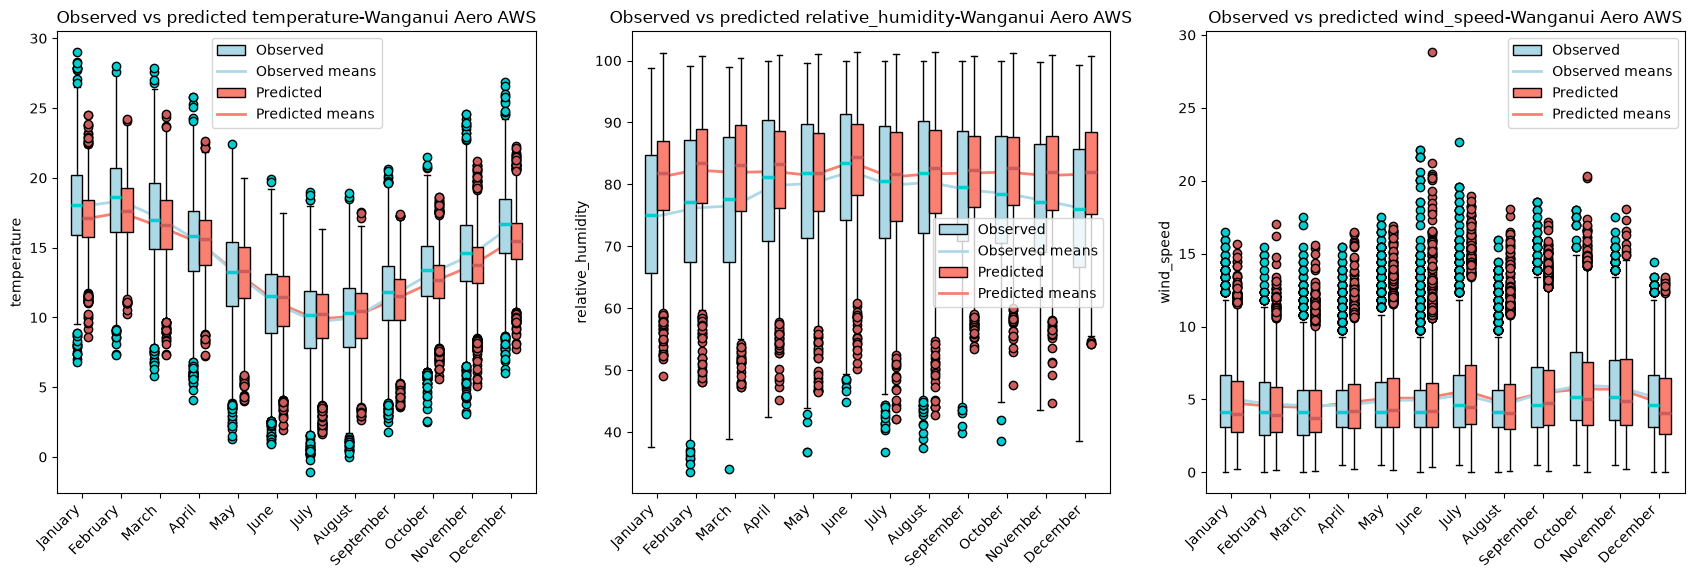

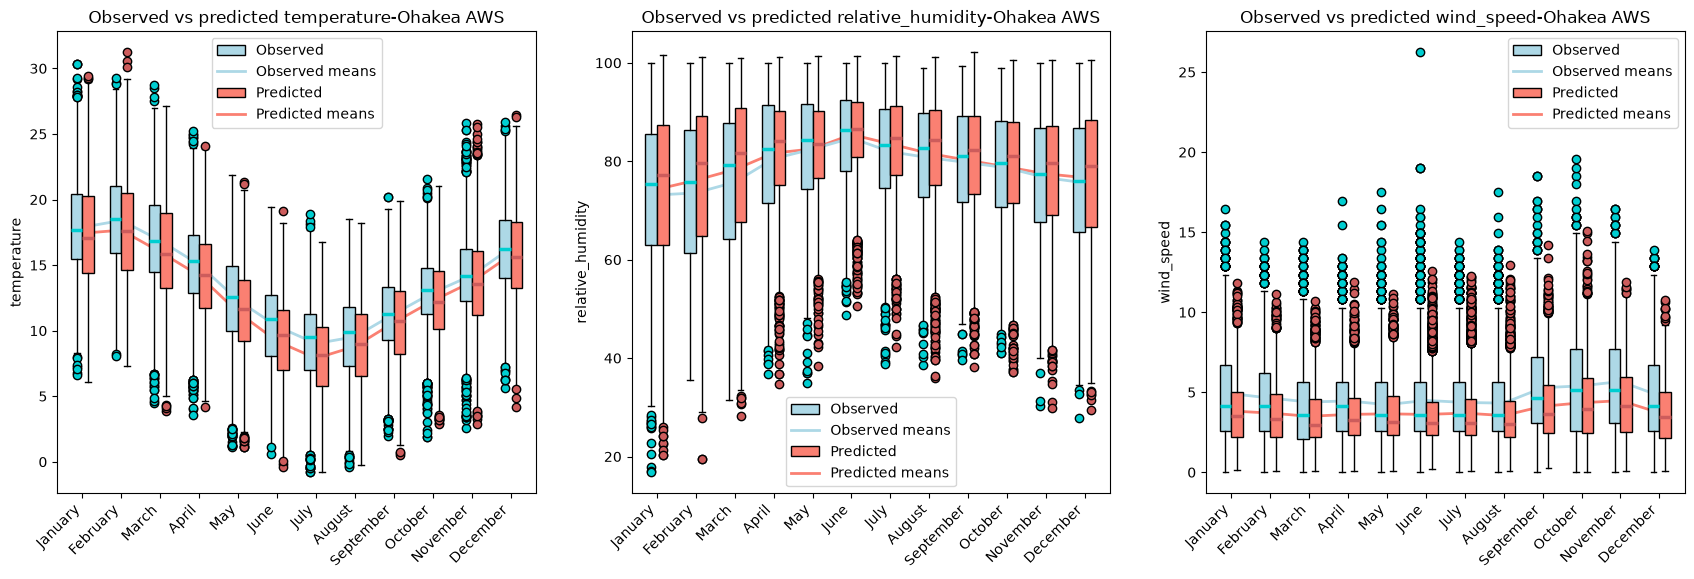

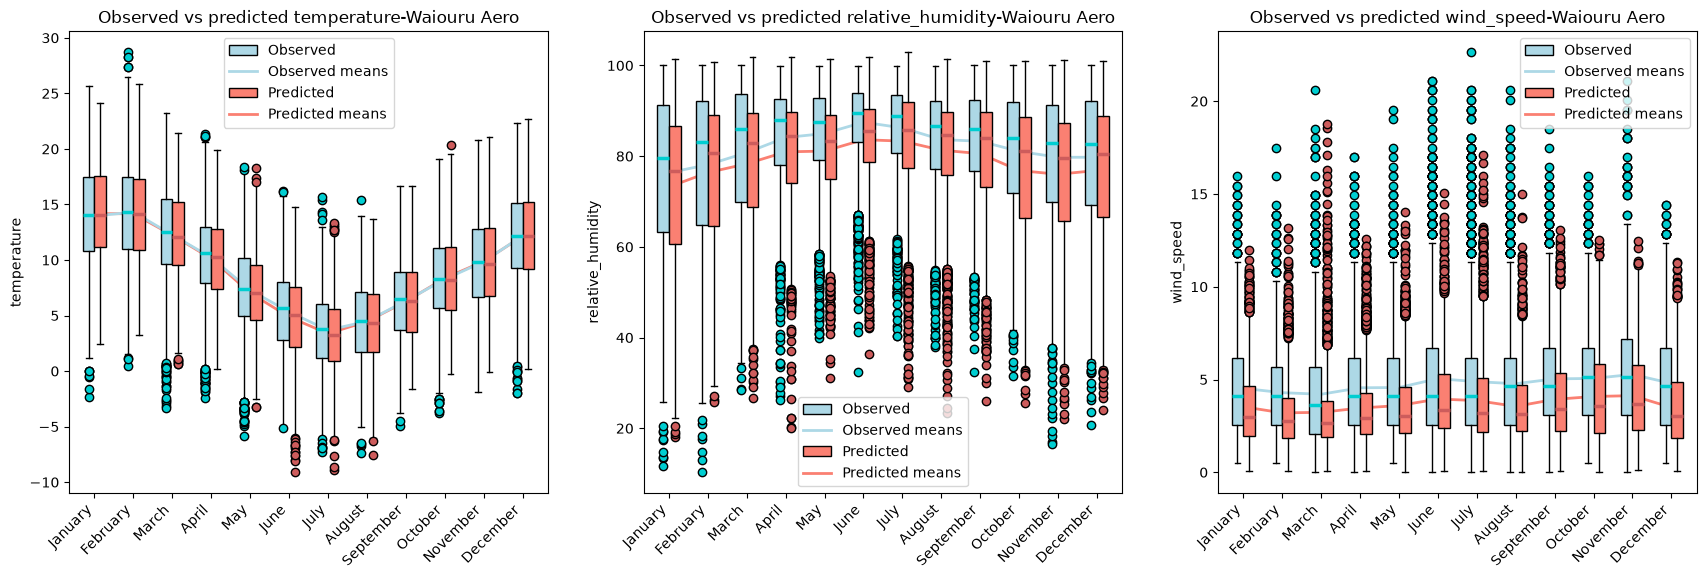

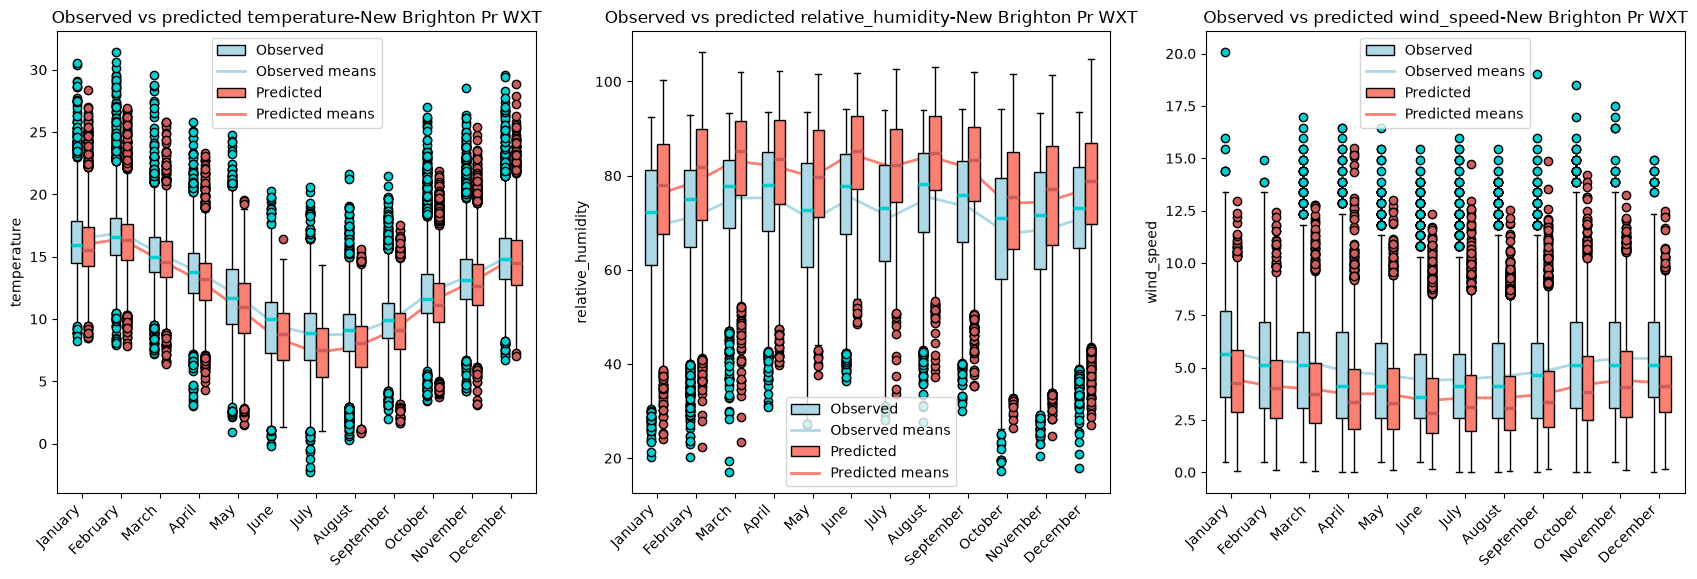

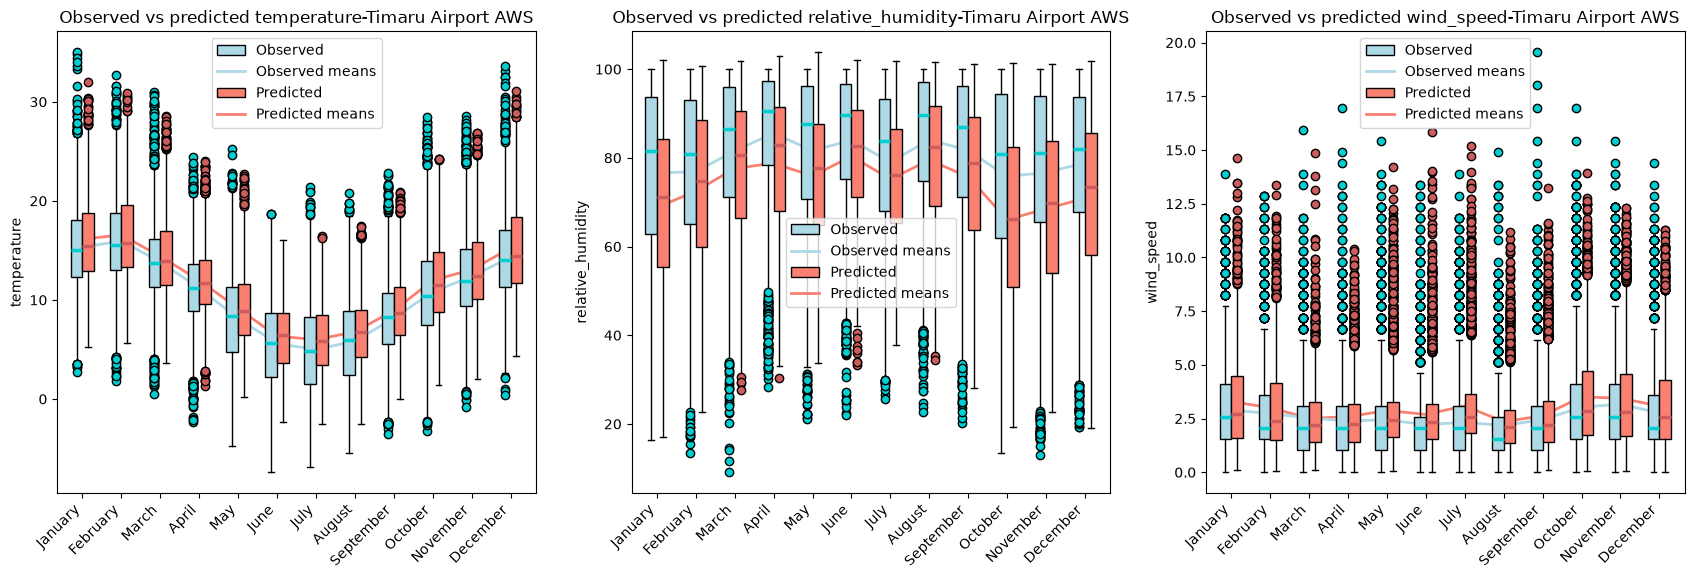

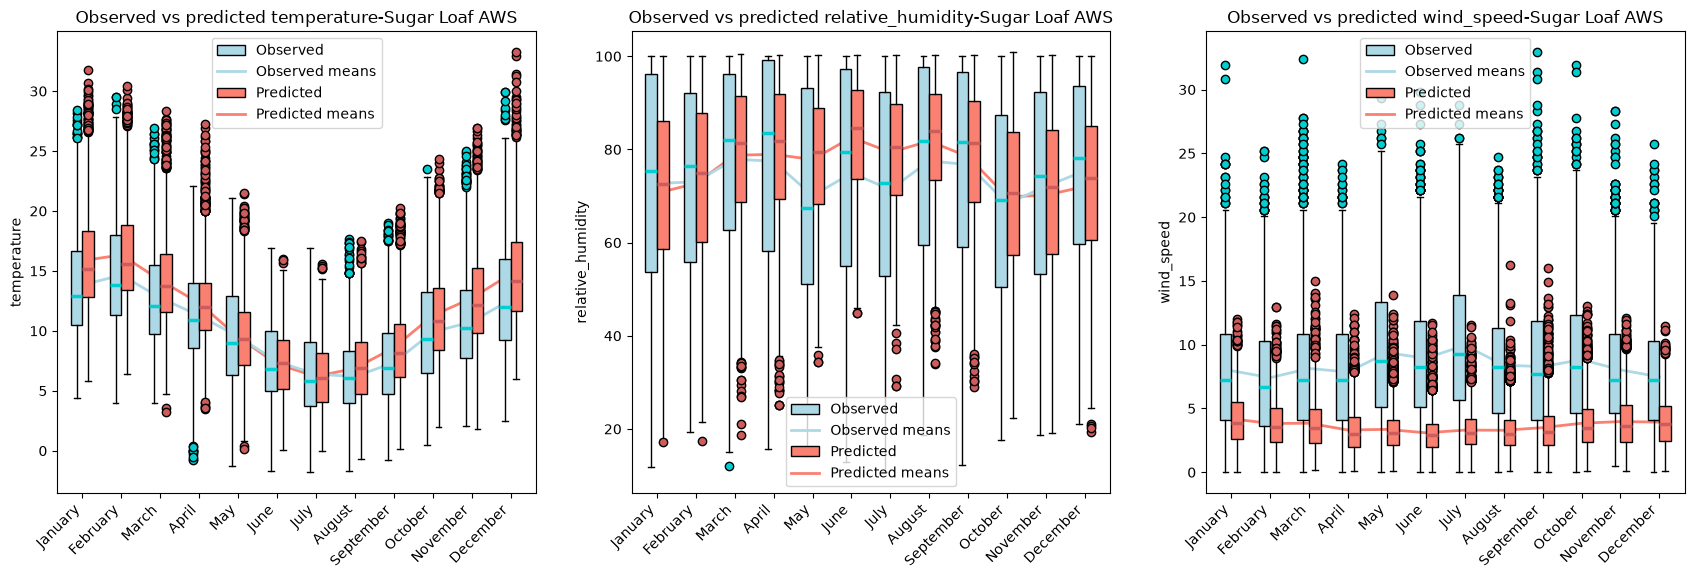

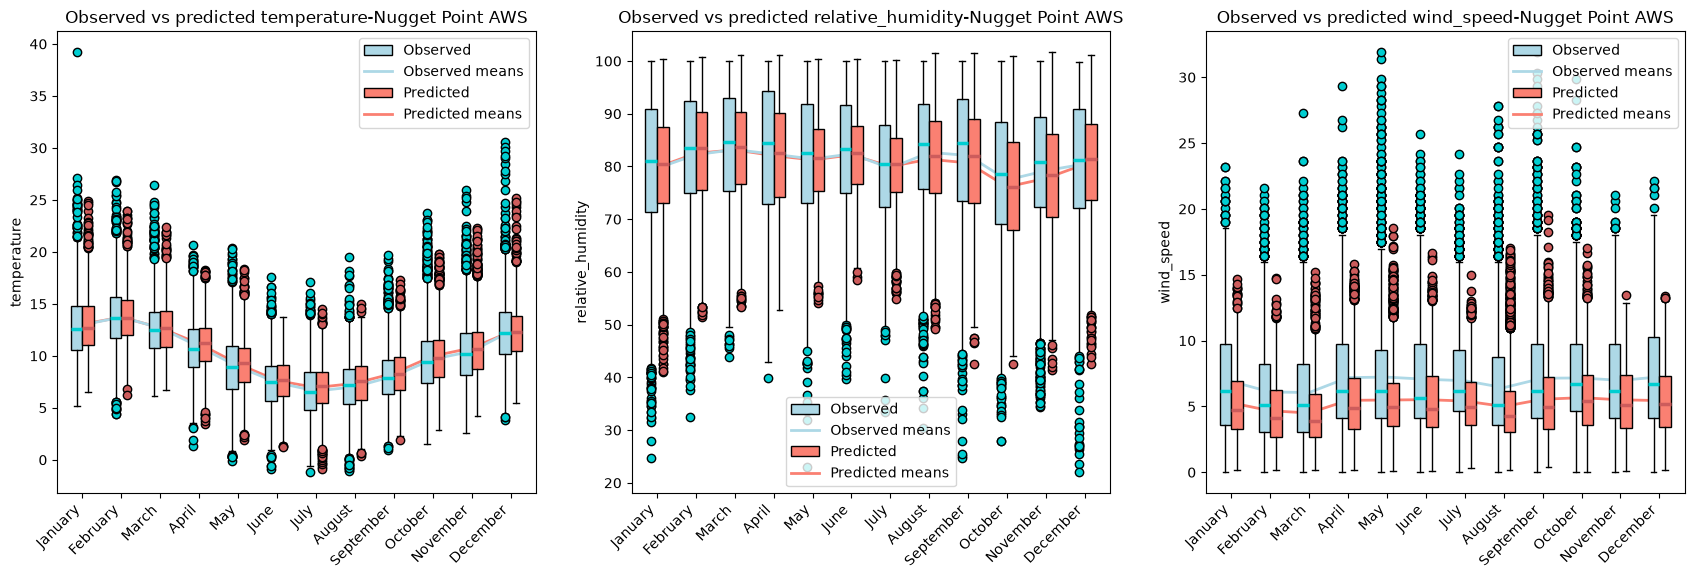

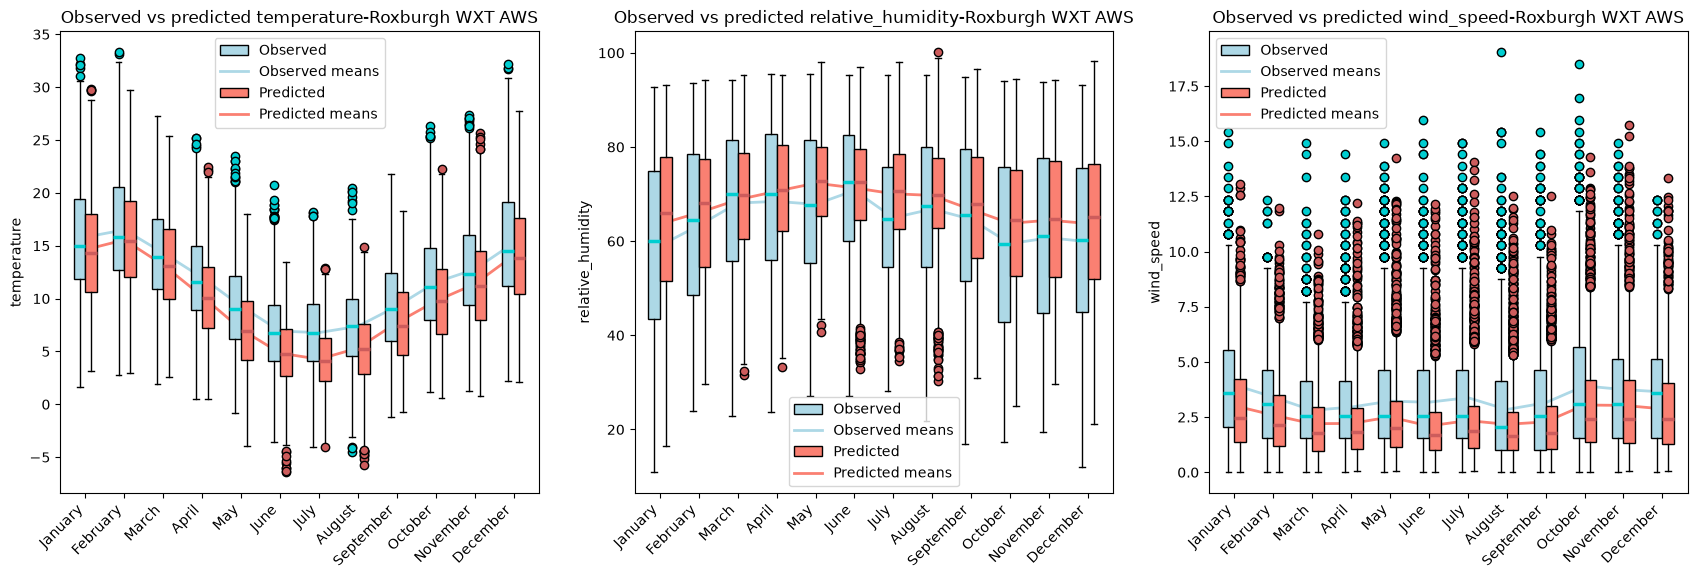

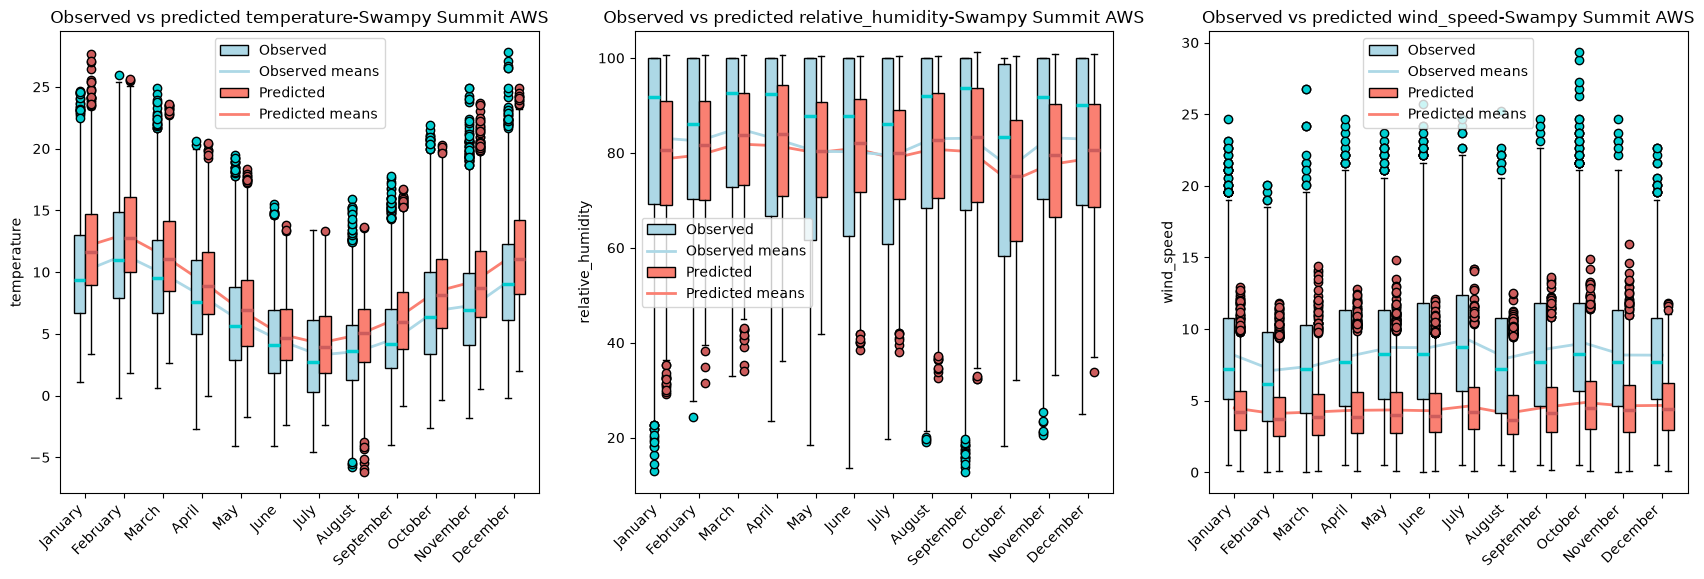

In [32]:
MONTH_LABELS = list(calendar.month_name[1:])
monthly_x_positions = np.arange(12, dtype=float)

for location in LOCATIONS:
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    
    for ix, variable in enumerate(VARIABLES):
        obs_raw = SOURCE_DATA[variable]['obs']
        pred_raw = SOURCE_DATA[variable]['pred']
        obs = obs_raw[variable].sel(location=location).dropna('time')
        mod = pred_raw[variable].sel(location=location).dropna('time')
    
        pred_grp, obs_grp = group_datasets(mod, obs, 'time.month')
        pred_values = [group_array.values for _, group_array in pred_grp]
        obs_values =  [group_array.values for _, group_array in obs_grp]
    
        show_box_plot(axes[ix], obs_values, pred_values, variable, 'monthly', location, monthly_x_positions, MONTH_LABELS)
    plt.show()


#### Diurnal plots

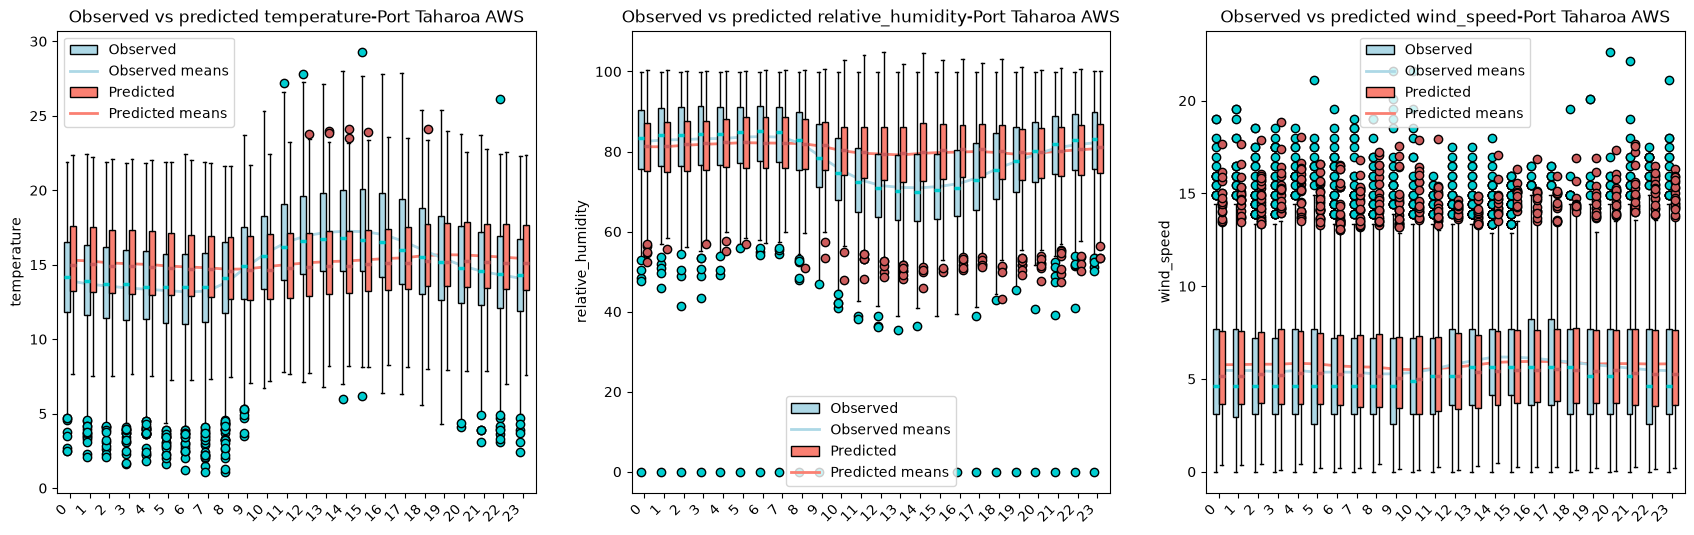

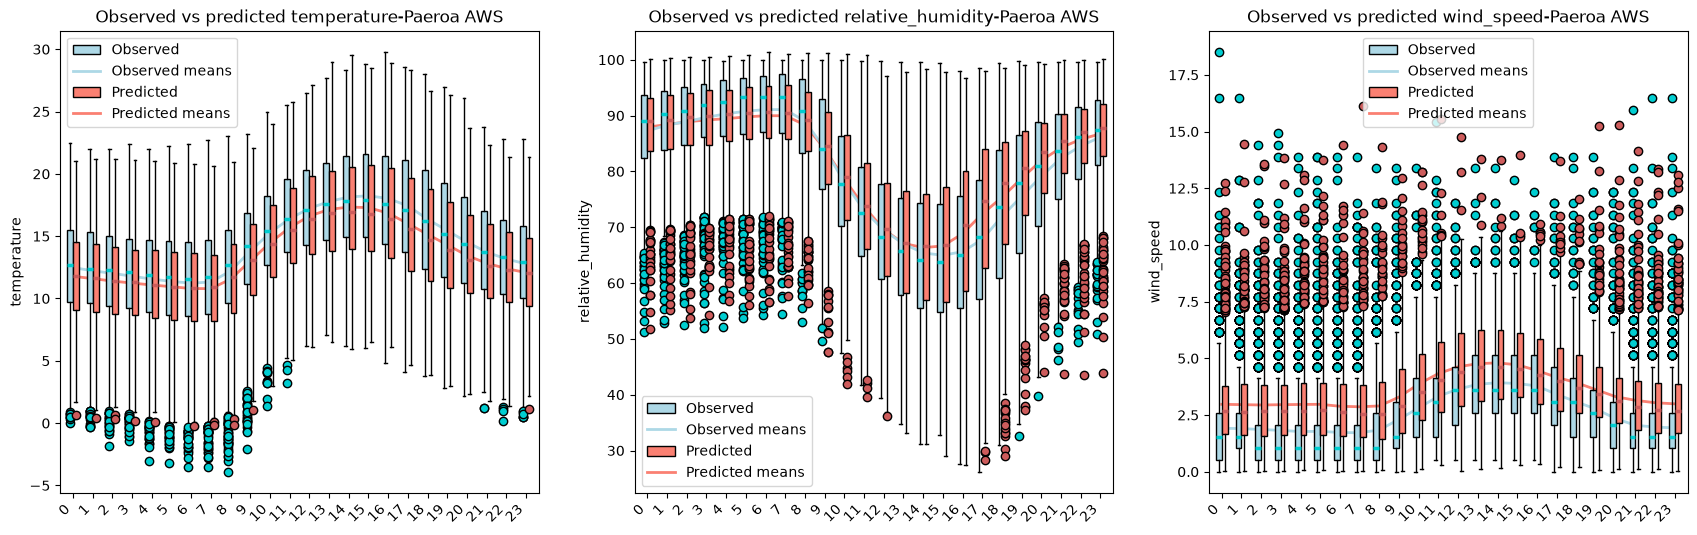

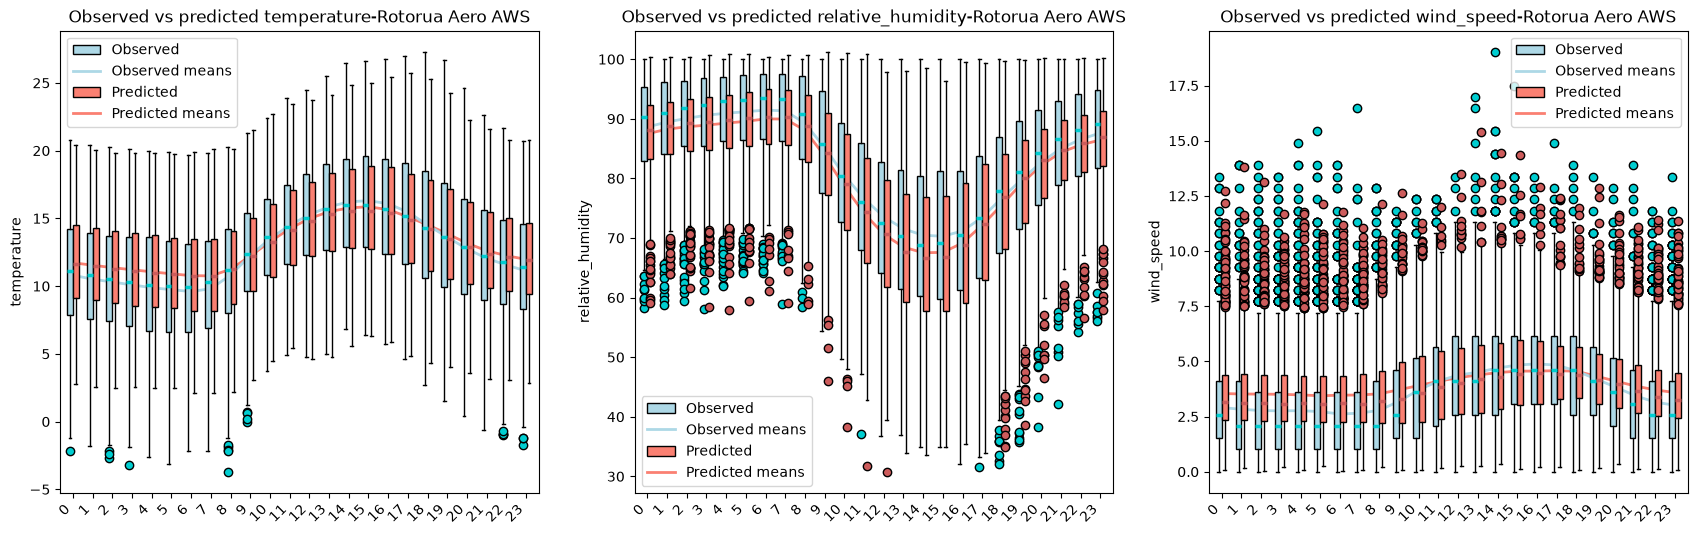

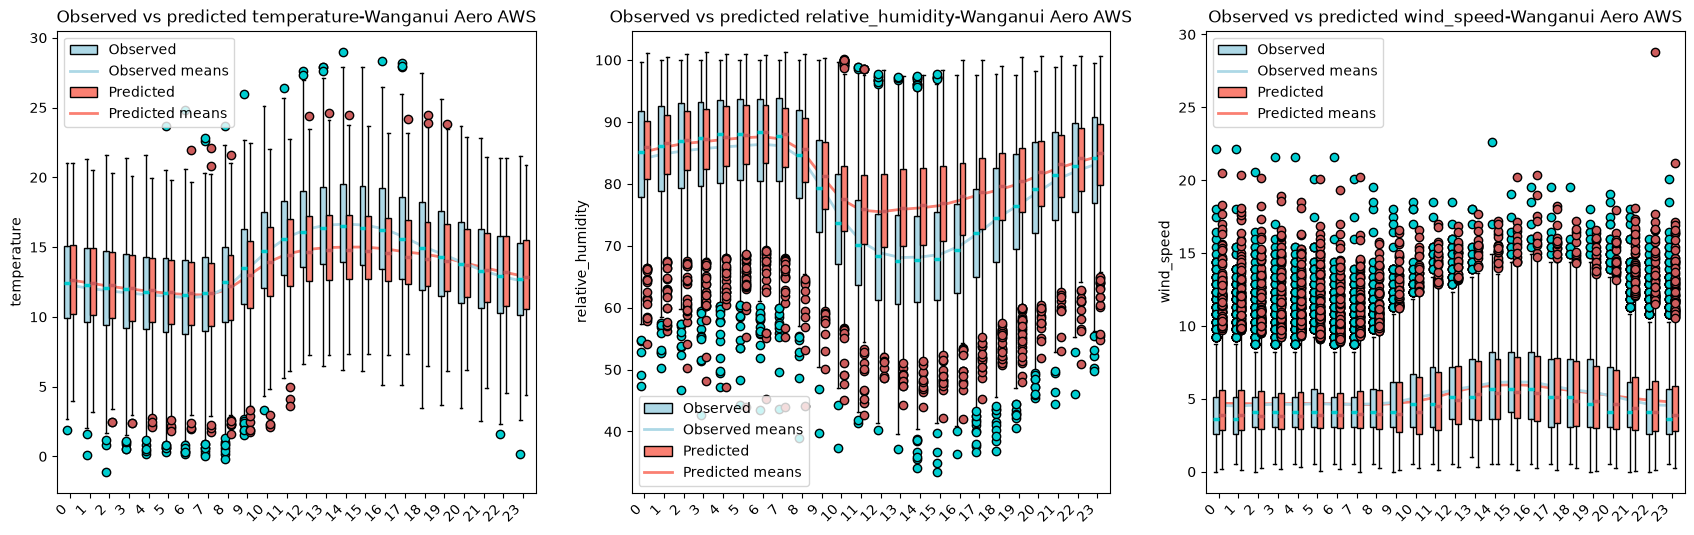

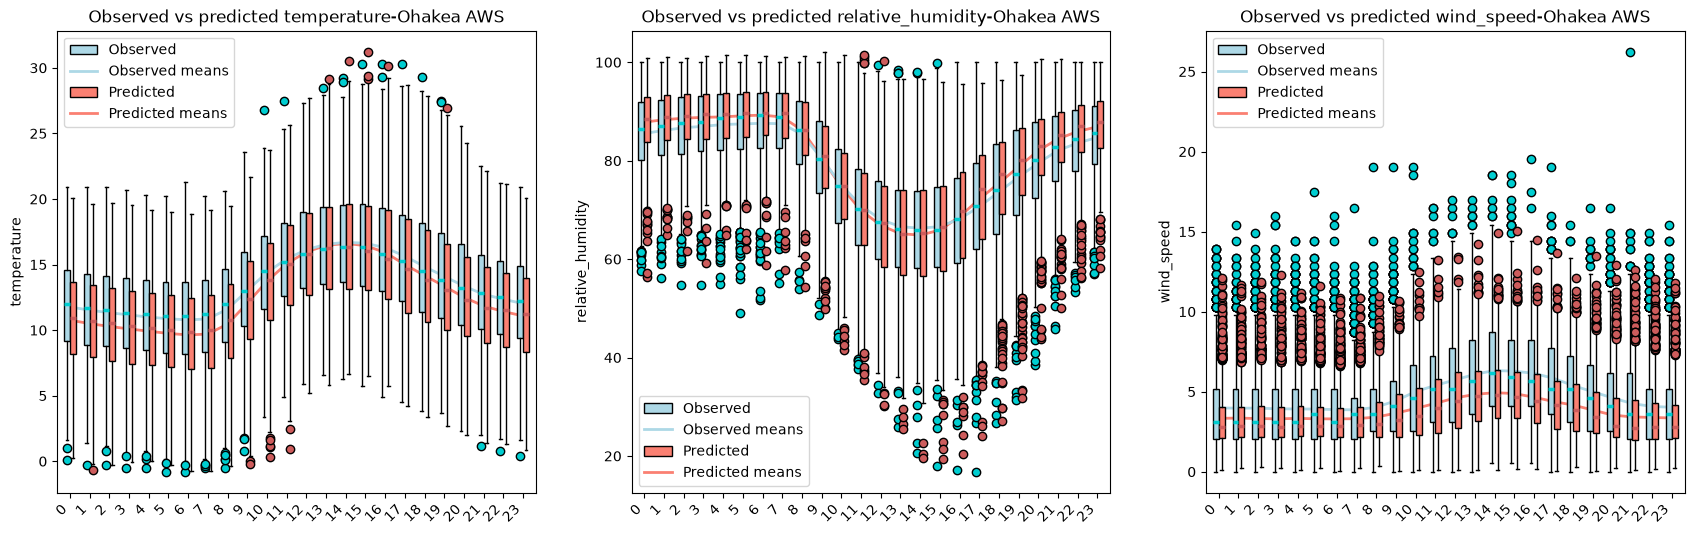

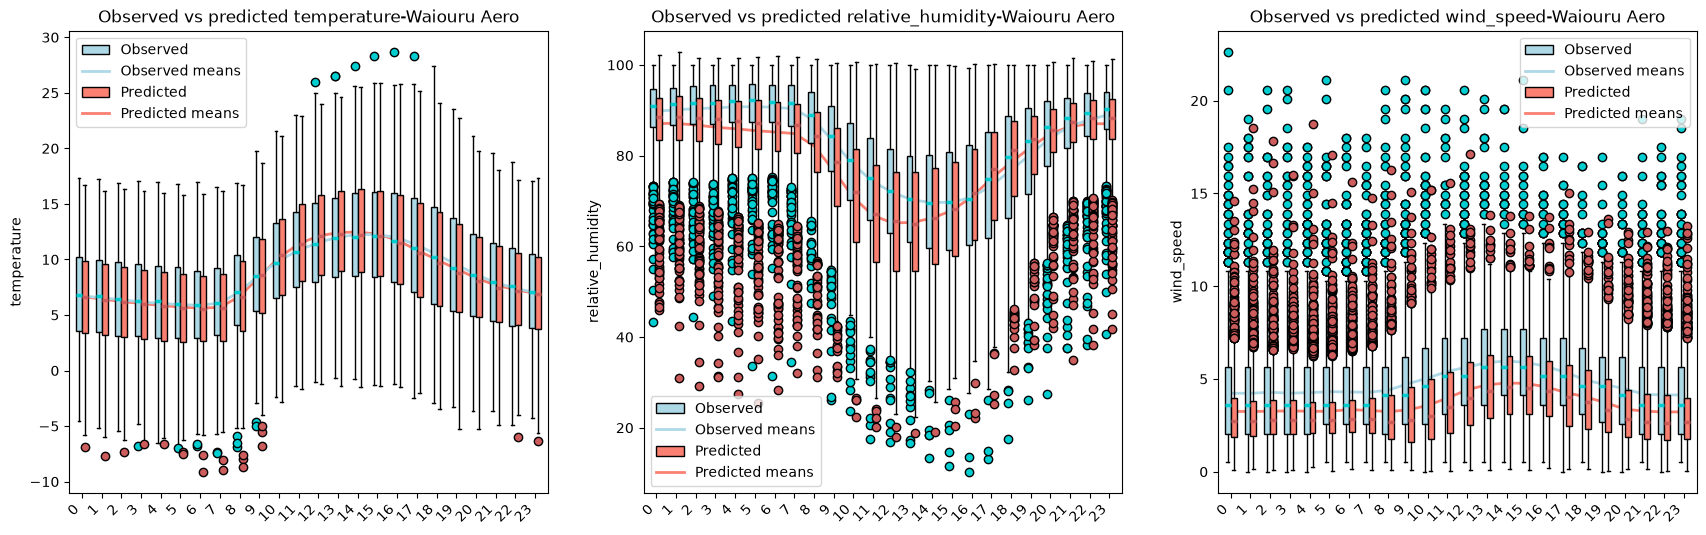

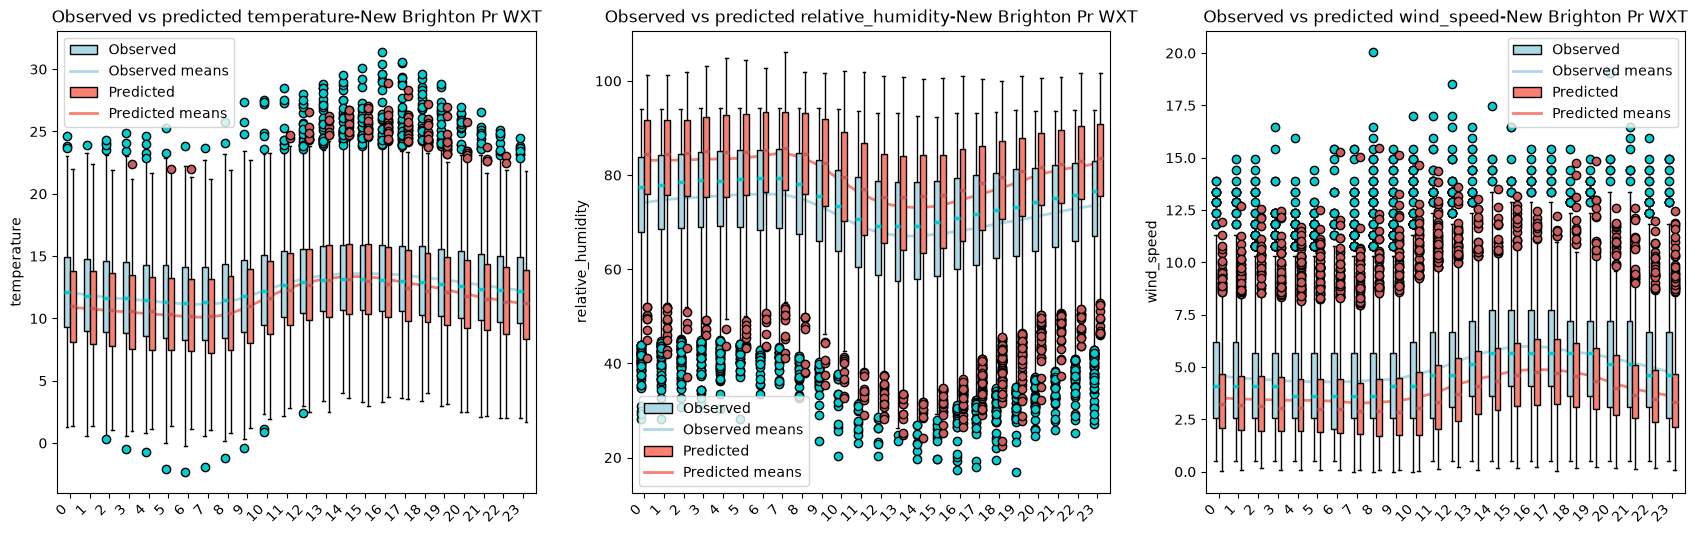

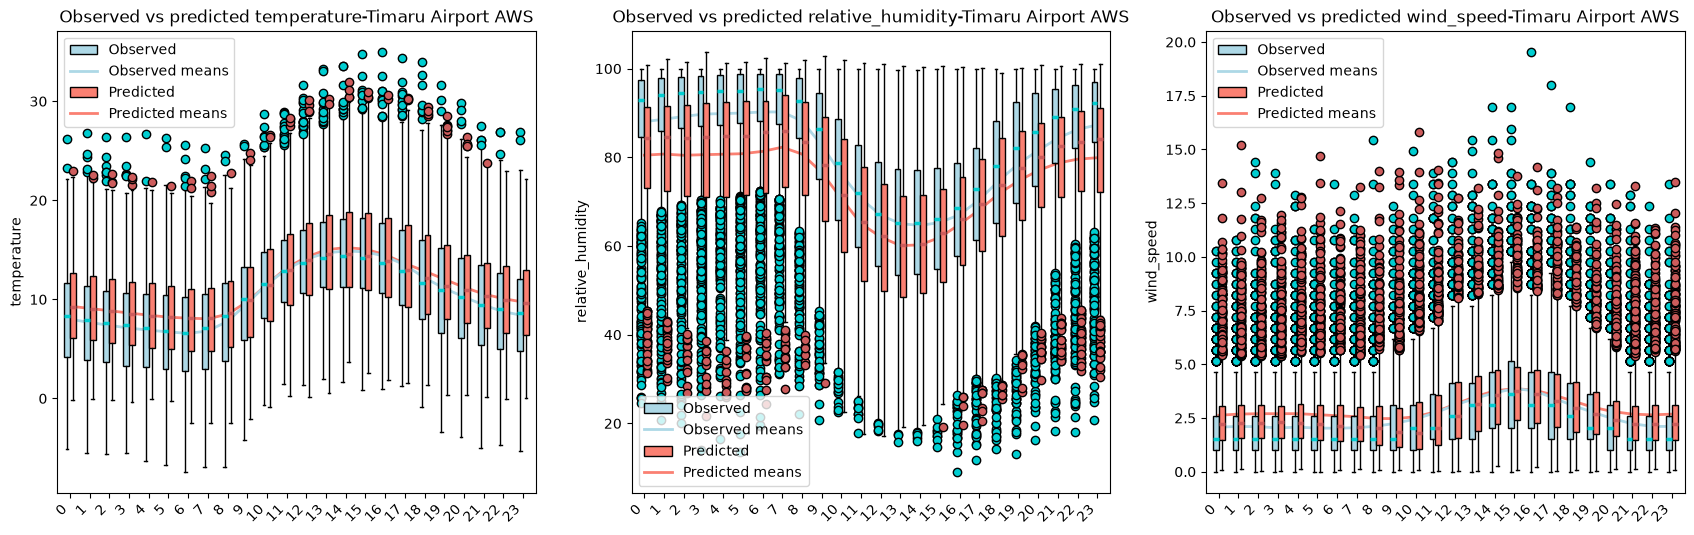

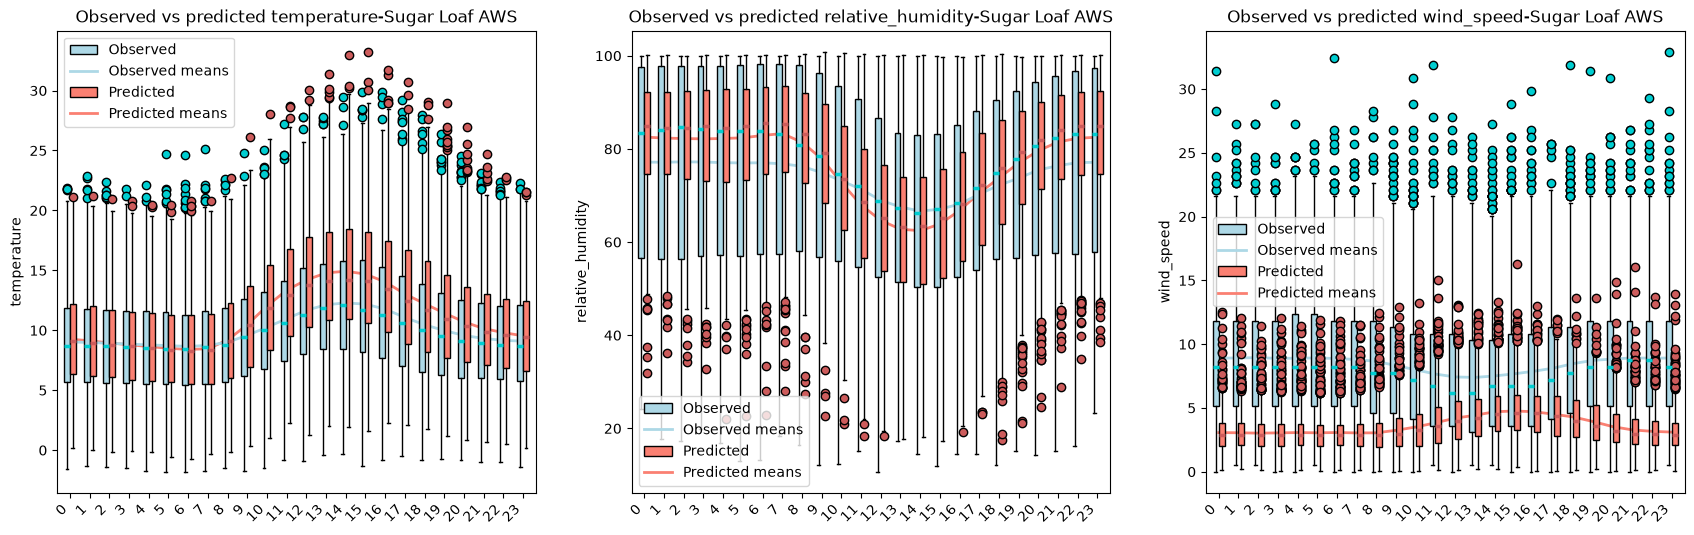

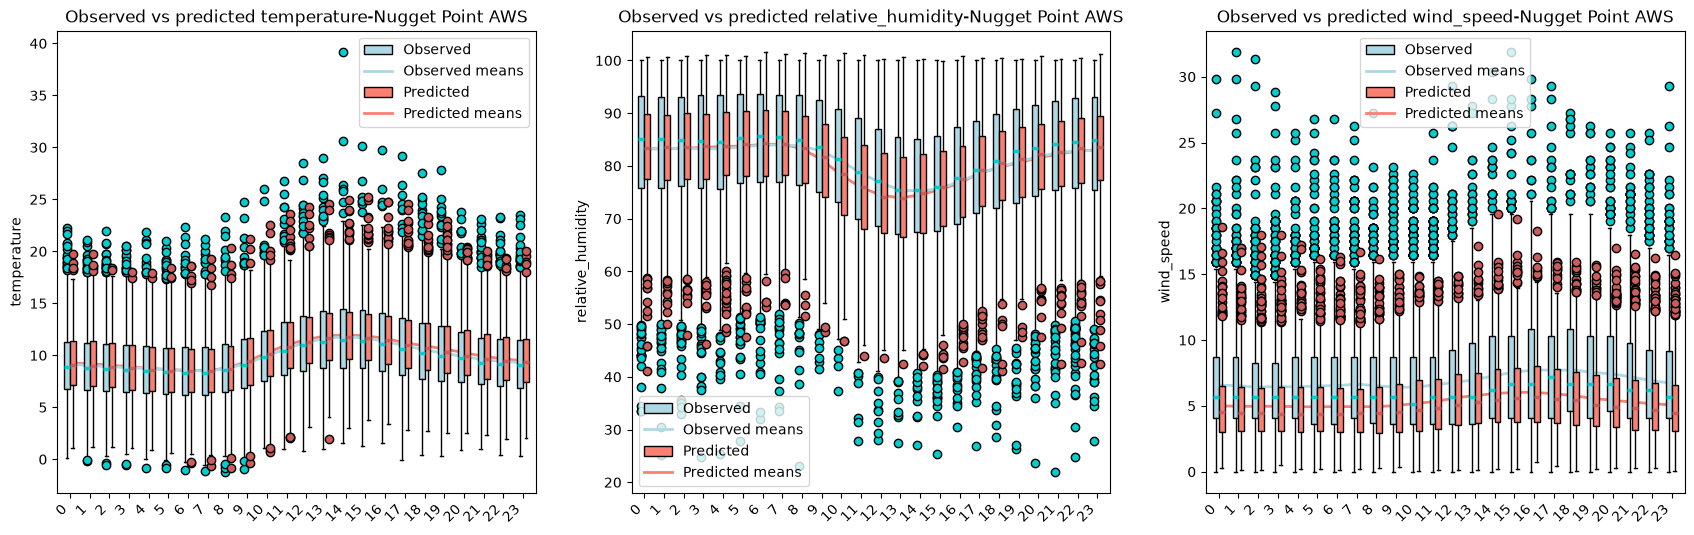

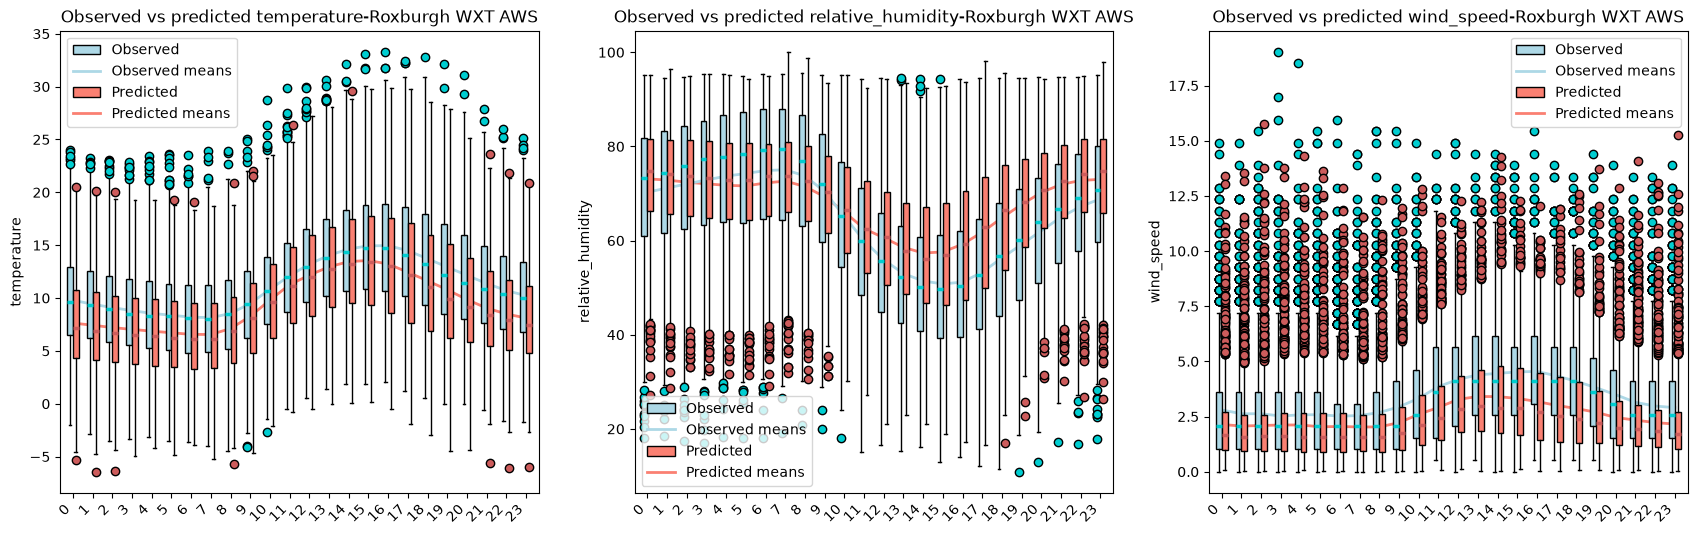

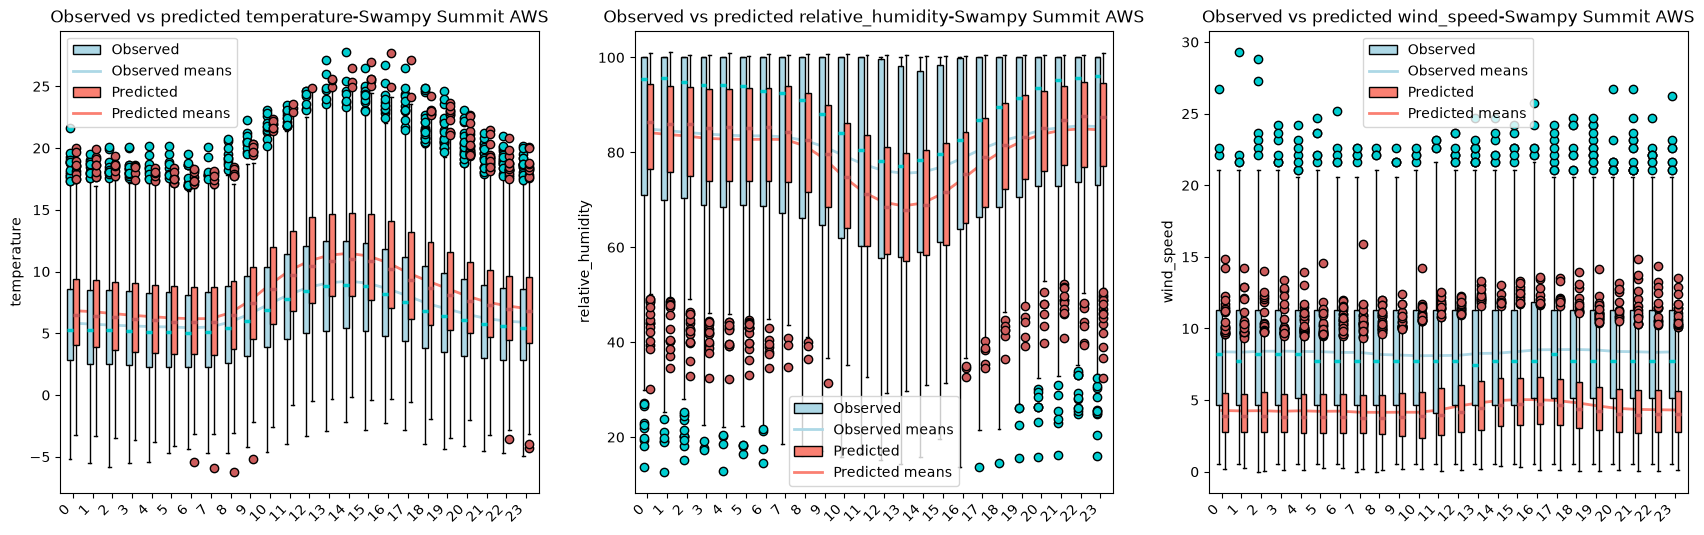

In [33]:
HOUR_LABELS = np.arange(24)
hourly_x_positions = np.arange(24, dtype=float)

for location in LOCATIONS:
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    
    for ix, variable in enumerate(VARIABLES):
        obs_raw = SOURCE_DATA[variable]['obs']
        pred_raw = SOURCE_DATA[variable]['pred']
        obs = obs_raw[variable].sel(location=location).dropna('time')
        mod = pred_raw[variable].sel(location=location).dropna('time')
    
        pred_grp, obs_grp = group_datasets(mod, obs, 'time.hour')
        pred_values = [group_array.values for _, group_array in pred_grp]
        obs_values =  [group_array.values for _, group_array in obs_grp]
    
        show_box_plot(axes[ix], obs_values, pred_values, variable, 'hourly', location, hourly_x_positions, HOUR_LABELS)
    plt.show()


#### Discussion

##### Temperature

Across all 12 weather stations, the seasonal temperature cycles are fairly accurately captured by the WRF model. The predictable nature of temperature changes across seasons and across the hours of the day means that this variable is easier to predict than other weather phenomena.

Most accurate are the coastal low elevation sites. Three of the four inland low altitude stations (Paeroa, Ohakea, Roxburgh) exhibit a small but consistent cold bias; while the fourth (Timaru) has a small consistent positive bias. Although I included Timaru as an 'inland' site, it's considerably closer to the sea than the other three stations, and accuracy there is similar to that of the other coastal sites.

There is a warm bias at two high altitude stations: at Swampy Summit and Sugar Loaf the model consistently predicted temperatures higher than observations. The WRF model takes an average altitude across the grid cells, so in a valley floor (like the Glentanner example from Part A) the average elevation can be higher than the station and the model ends up with a cold bias because it estimates for that higher elevation. But on a summit the actual station sits higher than the averaged elevation so the prediction is for a lower altitude than the station and hence predictions are warmer.

This is backed up by the better performance at Waiouru. Waiouru is also high altitude but sits on a broad inland plateau (therefore getting a more accurage average elevation), whereas Swampy Summit and sugar loaf are isolated peaks and are closer to the ocean.

Port Taharoa (coastal, low) hourly data has very flat temperature predictions, overestimating the overnight lows and underestimating the daytime highs. But when viewed monthly the model overall tracks quite well.

##### Relative Humidity

Humidity predictions are generally closer to observations over the winter months, with the exception being Sugar Loaf where the summer predictions are more accurate and winter months are drier than predicted. 

Wanganui and New Brighton, both coastal sites, both show quite a consistent wet bias. Although they are on different islands and opposite coasts, they are both very close to sea level (8m elevation) and the 4km grid cells containing these sites could cover more ocean than land, causing the WRF model to over-estimate humidity.

Three of the four high altitude stations exhibit a dry bias, but the fourth, Sugar Loaf, has a slight wet bias. Sugar Loaf lies on the Port Hills adjacent to Lyttelton Harbour, so it is likely the proximity to this harbour that makes the model exaggerate the humidity prediction.

Of the high altitude sites with dry bias, the most extreme is at Swampy Summit. Observed humidity at this site is quite consistently between 70 and 100%. The model however predicts consistently lower and with a much smaller variability. This location is quite a steep peak and is also close to the ocean, making it particularly difficult to predict.

The box plots show that relative humidity observations tend to be a lot more variable than the WRF predictions.

##### Wind Speed

Inland sites such as Paeroa, Ohakea, and Roxburgh show quite low average wind speeds that don't vary much with the seasons. The model still seems to underestimate winds though even at this calm locations, with a lot of high wind outliers.

Sugar Loaf and Swampy Summit, both high altitude locations and both fairly near the coast, both show the WRF model grossly underestimating wind. The box plots for Sugar Loaf only overlap during the summer months and even then only slightly. The model predicts a very small range of wind speeds while the observations are much more variable - the predicted outlier values are only in line with the upper quartile of the observations.

7 of the 12 locations (Ohakea, Waiouru, New Brighton, Sugar Loaf, Nugget Point, Roxburgh, Swampy Summit) are windier than predicted and are also more variable than predicted (the observation boxes on the plots are much taller than the prediction boxes).

On the hourly plots, you can see that inland locations tend to have a daily pattern of wind speeds, with the median rising in the afternoons (Paeroa, Ohakea, Timaru and Roxburgh all show this clearly), whereas the higher altitude sites have a flatter profile through the day.

### 2b: Monthly and diurnal model performance per variable per station

#### Supporting code

`_safe_stat` is a function that runs another statistical function on the provided model and observation data, but only if the datasets contain at least 10 pairs of valid data points.

In [34]:
def _safe_stat(pred, obs, func, min_pairs=10):
    mask = ~np.isnan(pred) & ~np.isnan(obs)
    if mask.sum() < min_pairs:
        return np.nan
    return float(func(pred[mask], obs[mask]))

`map_metrics` calcualtes RMSE, R$^2$, and IoA for one grouped dataset

In [35]:
def map_metrics(group_ds, min_pairs=10):
    kw = dict(input_core_dims=[["time"], ["time"]], vectorize=True, output_dtypes=[float])
    rmse = xr.apply_ufunc(_safe_stat, group_ds["pred"], group_ds["obs"], kwargs={"func": he.rmse, "min_pairs": min_pairs}, **kw)
    r2   = xr.apply_ufunc(_safe_stat, group_ds["pred"], group_ds["obs"], kwargs={"func": he.r_squared, "min_pairs": min_pairs}, **kw)
    ioa  = xr.apply_ufunc(_safe_stat, group_ds["pred"], group_ds["obs"], kwargs={"func": he.d, "min_pairs": min_pairs}, **kw)
    
    return xr.Dataset({"rmse": rmse, "r2": r2, "ioa": ioa})

`compute_grouped_metrics` takes a model and an observed dataset and the groupby function, performs the grouping, and then runs the `map_metrics` function over the grouped data to compute the metrics.

In [36]:
def compute_grouped_metrics(pred_ds, obs_ds, groupby, min_pairs=10):
    pred_ds = de_dupe_times(pred_ds)
    obs_ds = de_dupe_times(obs_ds)
    pred_locs, obs_locs = xr.align(pred_ds, obs_ds, join="inner")
    combined = xr.merge(
        [
            pred_locs.rename({v: "pred" for v in pred_locs.data_vars}),
            obs_locs.rename({v: "obs" for v in obs_locs.data_vars}),
        ],
        compat="override",
        join="override",
    )
    combined = combined.load()
    grouped = combined.groupby(groupby)
    mapped = grouped.map(map_metrics)
    return mapped


In [37]:
# Given a set of grouped data, and the name that they're grouped by, calculate the three metrics
def matrices_from_grouped(grouped, grouping_name):
    loc_names = list(LOCATIONS.keys())
    monthly = grouped.sortby(grouping_name).reindex(location=loc_names)
    rmse = grouped["rmse"].transpose("location", grouping_name).values
    r2 = grouped["r2"].transpose("location", grouping_name).values
    ioa = grouped["ioa"].transpose("location", grouping_name).values
    return rmse, r2, ioa

In [38]:
MONTH_LABELS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec' ]
HOUR_LABELS = np.arange(24)
LOC_NAMES = list(LOCATIONS.keys())

def plot_metric_heatmaps(variable, y_names, x_names, rmse, r2, ioa):
    rotation = 0
    if (len(x_names) > 12):
        rotation = 45
    fig, axes = plt.subplots(1, 3, figsize=(19, 6))
    panels = [
        ('RMSE', rmse, 'YlOrRd', (np.nanmin(rmse), np.nanmax(rmse))),
        ('R2', r2, 'RdYlGn', (0,1)),
        ('IoA', ioa, 'RdYlGn', (0,1)),
    ]
    for ax, (title, mat, cmap, (vmin, vmax)) in zip(axes, panels):
        im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f'{variable} {title}')
        ax.set_xticks(range(len(x_names)))
        ax.set_xticklabels(x_names, rotation=45, ha='right')
        ax.set_yticks(range(len(y_names)))
        ax.set_yticklabels(y_names)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        for r in range(mat.shape[0]):
            for c in range(mat.shape[1]):
                if not np.isnan(mat[r, c]):
                    ax.text(c, r, f'{mat[r,c]:.2f}', ha='center', va='center', fontsize=6, rotation=rotation)
    plt.tight_layout()
    return fig

#### Monthly metrics

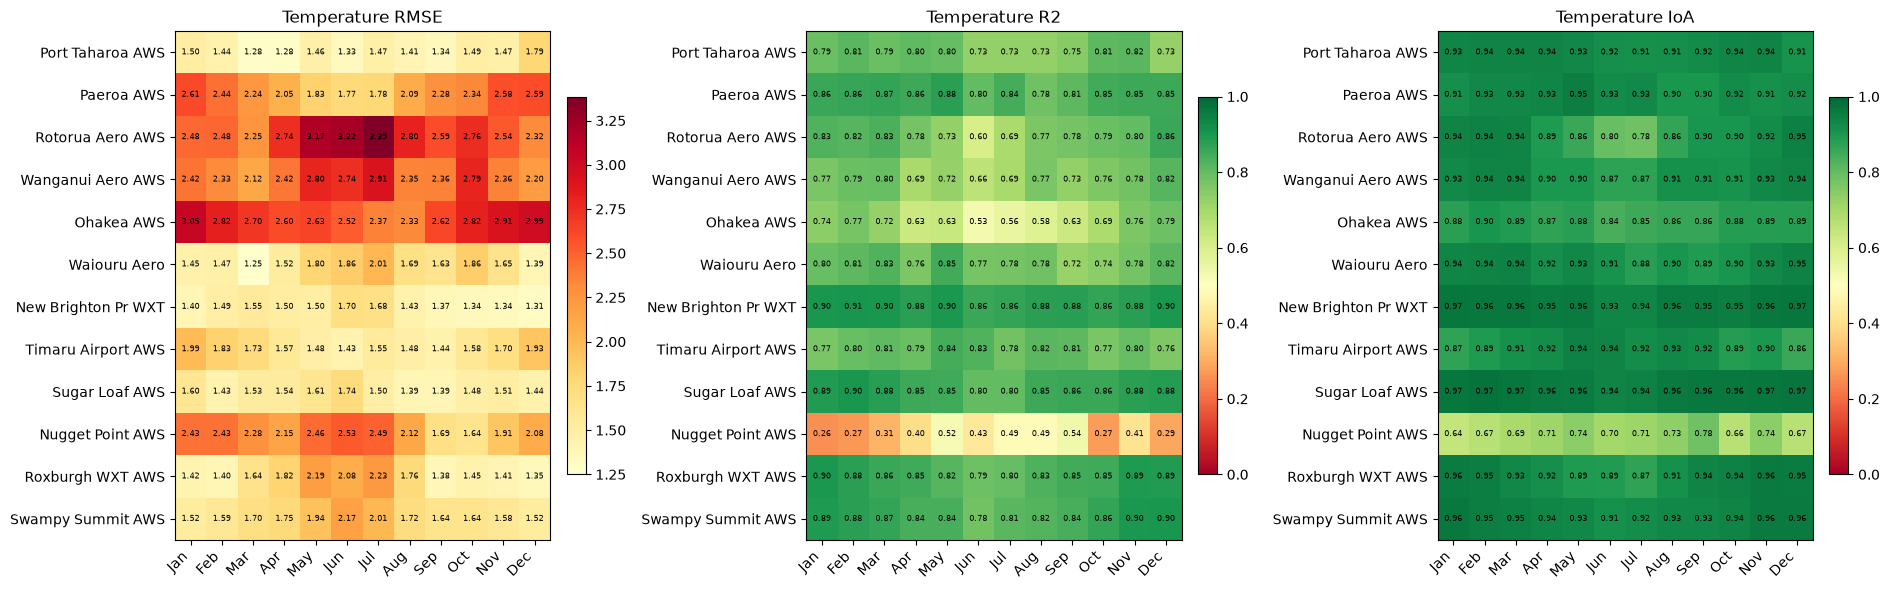

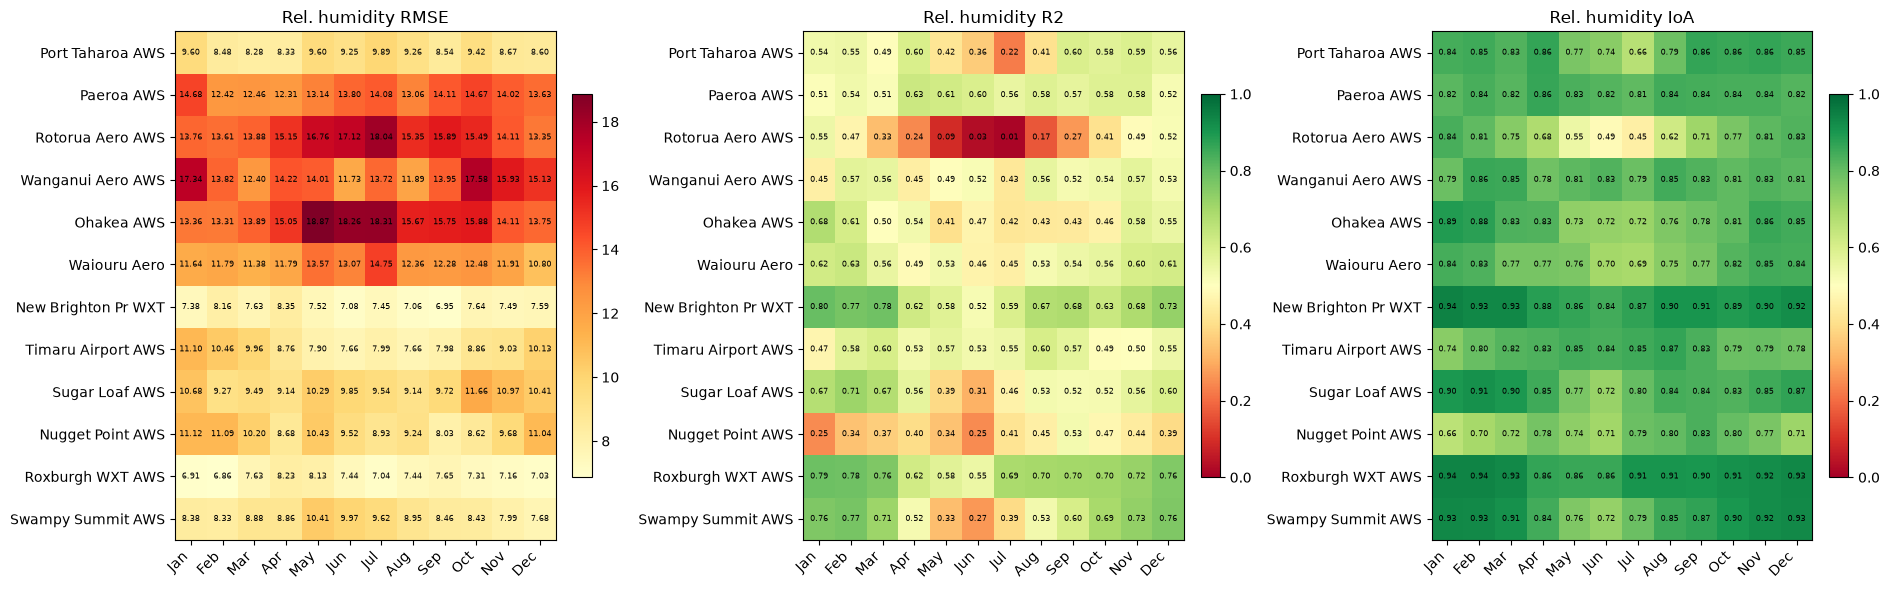

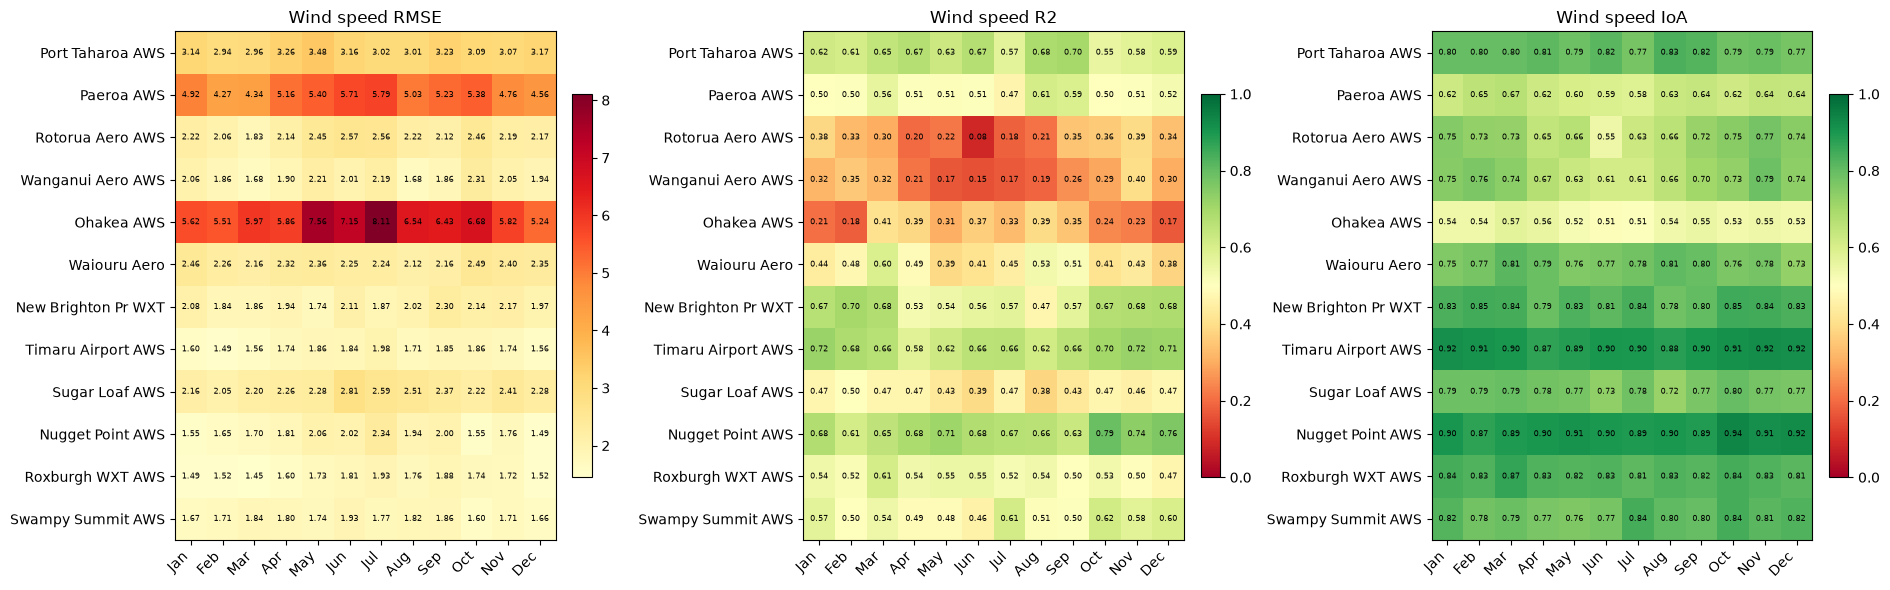

In [39]:
temp_monthly_stats = compute_grouped_metrics(temperature_model, temperature_obs, 'time.month')
t_m_rmse, t_m_r2, t_m_ioa = matrices_from_grouped(temp_monthly_stats, 'month')
t_m_fig = plot_metric_heatmaps('Temperature', LOC_NAMES, MONTH_LABELS, t_m_rmse, t_m_r2, t_m_ioa)
t_m_fig.show()

rh_monthly_stats = compute_grouped_metrics(relative_humidity_model, relative_humidity_obs, 'time.month')
rh_m_rmse, rh_m_r2, rh_m_ioa = matrices_from_grouped(rh_monthly_stats, 'month')
rh_m_fig = plot_metric_heatmaps('Rel. humidity', LOC_NAMES, MONTH_LABELS, rh_m_rmse, rh_m_r2, rh_m_ioa)
rh_m_fig.show()

ws_monthly_stats = compute_grouped_metrics(wind_speed_model, wind_speed_obs, 'time.month')
ws_m_rmse, ws_m_r2, ws_m_ioa = matrices_from_grouped(ws_monthly_stats, 'month')
ws_m_fig = plot_metric_heatmaps('Wind speed', LOC_NAMES, MONTH_LABELS, ws_m_rmse, ws_m_r2, ws_m_ioa)
ws_m_fig.show()

#### Diurnal metrics

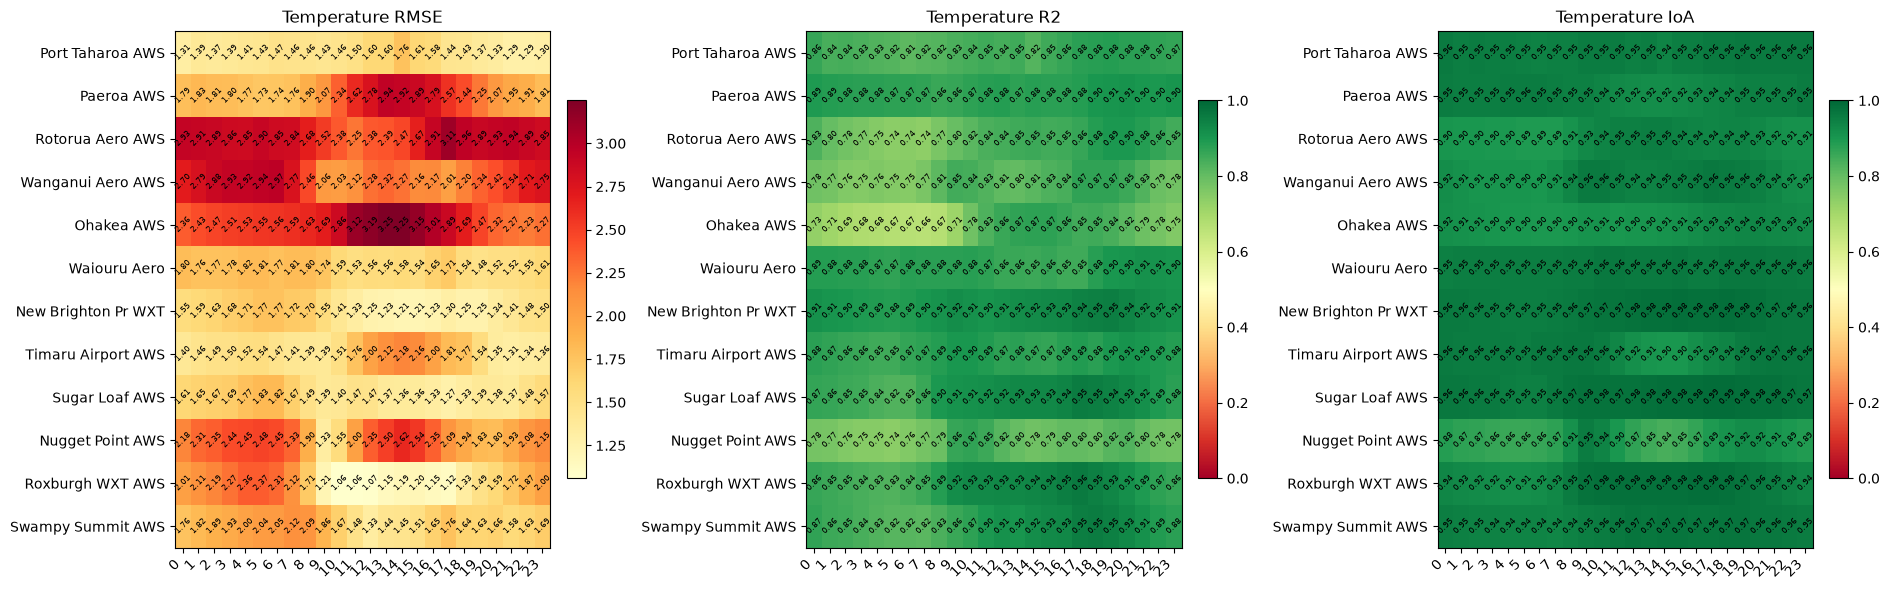

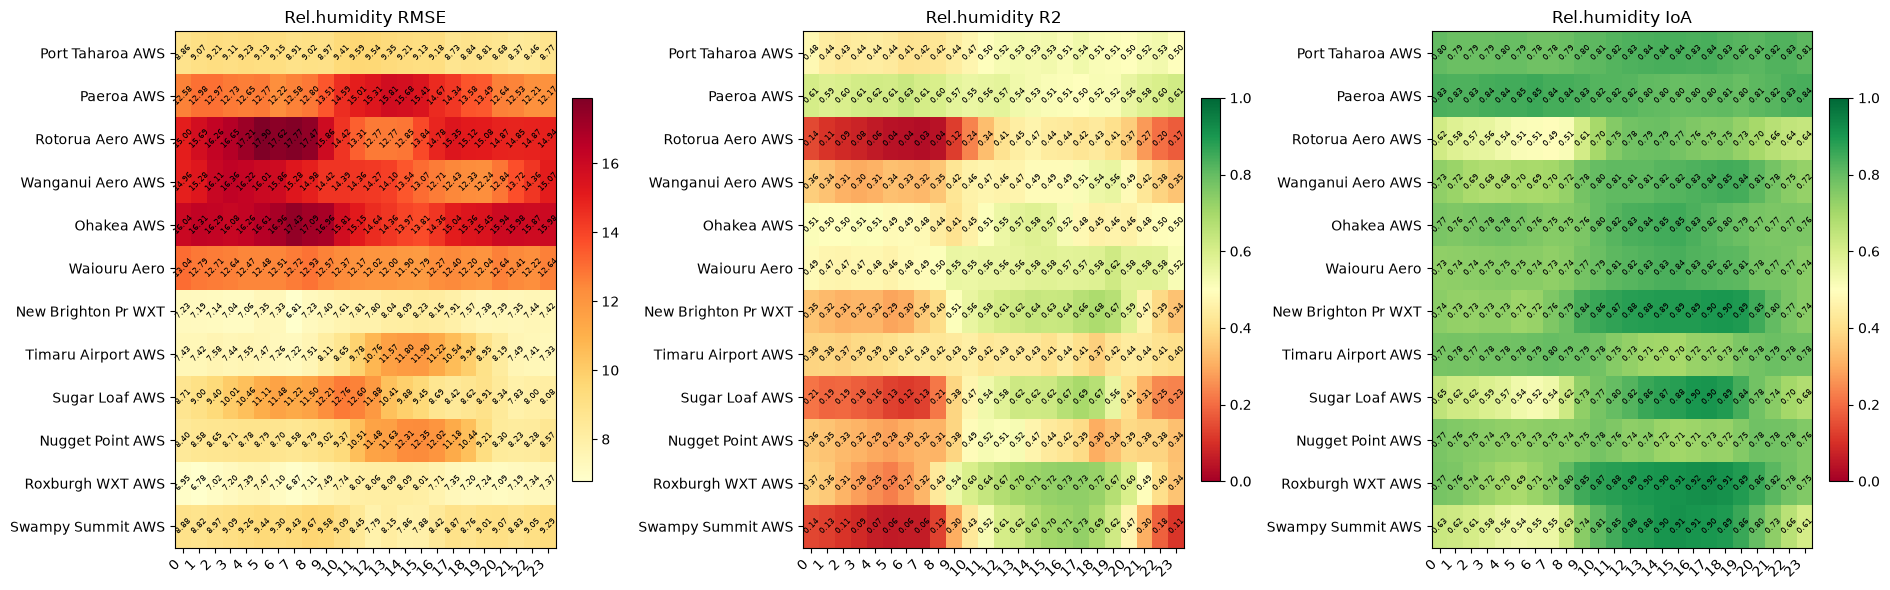

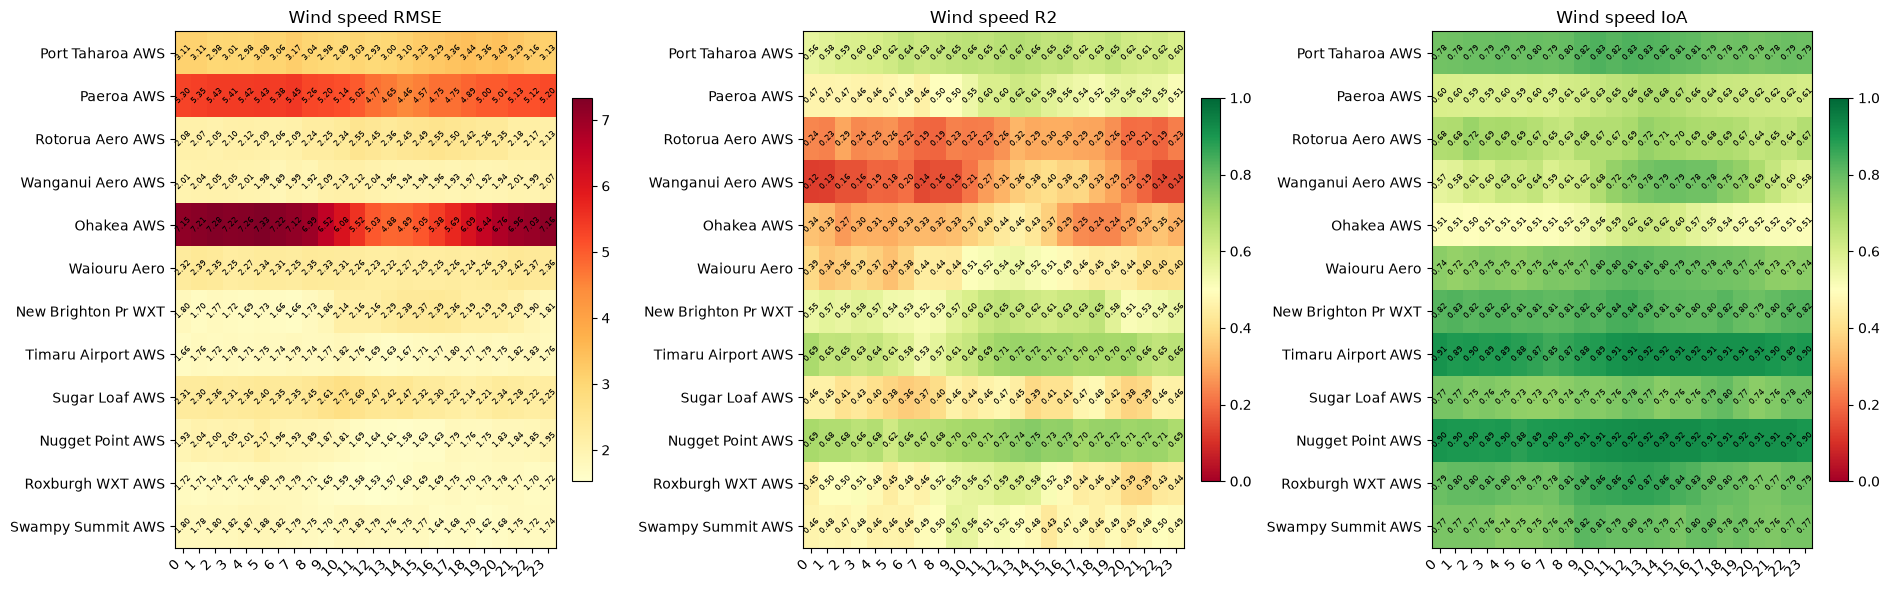

In [40]:

temp_diurnal_stats = compute_grouped_metrics(temperature_model, temperature_obs, 'time.hour')
t_d_rmse, t_d_r2, t_d_ioa = matrices_from_grouped(temp_diurnal_stats, 'hour')
t_d_fig = plot_metric_heatmaps('Temperature', LOC_NAMES, HOUR_LABELS, t_d_rmse, t_d_r2, t_d_ioa)
t_d_fig.show()

rh_diurnal_stats = compute_grouped_metrics(relative_humidity_model, relative_humidity_obs, 'time.hour')
rh_d_rmse, rh_d_r2, rh_d_ioa = matrices_from_grouped(rh_diurnal_stats, 'hour')
rh_d_fig = plot_metric_heatmaps('Rel.humidity', LOC_NAMES, HOUR_LABELS, rh_d_rmse, rh_d_r2, rh_d_ioa)
rh_d_fig.show()

ws_diurnal_stats = compute_grouped_metrics(wind_speed_model, wind_speed_obs, 'time.hour')
ws_d_rmse, ws_d_r2, ws_d_ioa = matrices_from_grouped(ws_diurnal_stats, 'hour')
ws_d_fig = plot_metric_heatmaps('Wind speed', LOC_NAMES, HOUR_LABELS, ws_d_rmse, ws_d_r2, ws_d_ioa)
ws_d_fig.show()


#### Discussion

I chose to present these metrics in heatmaps to help identify the points where the model and observations converge and diverge according to the metrics. By comparing the box plots and heatmaps, we can see how different metrics react to different types of error:
* Where the box plots show a constant bias the heatmaps tend to back this up with a spike in RMSE but without a significant drop in the R$^2$ value
* When the box plots show that the model is predicting a much tighter range of values, the heatmaps show that R$^2$ drops while the IoA remains stable

##### Temperature

The coastal low elevation sites tend to have both a close correlation on the box plots and good scores in the metrics. Nugget Point and Wanganui however stand out as examples of RMSE sensitivity to outliers. Although the box plots for both locations seem to show good agreement between the model and the observations, they also show that the observed outlier temperatures are quite a lot more extreme than predicted. Consequently these two sites have quite high RMSE values. Because RMSE squares every error, it quite heavily penalises large outliers. The other two coastal stations (Port Taharoa, New Brighton) show more moderate RMSE values and very stable R2 and IoA.

The warm bias noted at Swampy Summit and Sugar Loaf does not show up in the metric - R$^2$ hides the bias completely, RMSE shows there is a small and consistent error but not its direction, and IoA is stable because the bias is constant. This shows the usefulness of box plots and underlines the importance of not relying only on metrics. 

##### Relative Humidity

Coastal locations show up with poorer metrics in the heatmaps, likely due to the model biasing predictions towards the ocean portion of their grid squares. Nugget Point again shows up with low scores across all metrics, particularly in the summer months. The box plots highlight that the summer months yielded some very dry outliers at Nugget Point, considerably drier than was predicted. Wanganui also shows a similar pattern. New Brighton shows a constant wet bias through the year which shows up as a consistent 6-7% RMSE. 

At the inland site of roxburgh, humidity observations and predictions are both fairly flat between 9pm and 7am, creating poor R$^2$ values since R$^2$ doesn't work when both values are tending towards flatness and isn't a variance to explain. The RMSE for that period is conversely low because the models broadly agree, whereas RMSE spikes during the afternoons, where we can see from the Roxburgh hourly box plot that the gap between observations and predictions grows to its largest.

##### Wind Speed

R$^2$ and IoA values are very different for wind speed, so the box plots are necessary to help explain them. The overall trend in wind speed over the day is fairly well predicted at most sites, creating a generally green IoA heatmap, with a notable exception at Ohakea: here the observed outliers are much higher than the predictions, creating a strong RMSE spike. The model and observations diverge quite strongly in the middle of the day creating a varied R$^2$ value, but the index of agreement remains quite low because there is a quote constant underestimation of the wind speed.  Ohakea's monthly patterns are quite simliar, with much higher observed outliers that peak through the winter months, but a consistent underestimation throughout the year.

I was surprised at the good metric values for wind speed at Swampy Summit and Sugar Loaf. The box plots at both stations show a consistent underestimation of wind speed, and some extreme observed outliers. But the RMSE will be an average over all of the data points in the 3 years of data, and the outlier values are very few. So although they are extreme, they are not frequent enough to strongly affect the RMSE score. This is another case where the box plots tell an important part of the story - the metrics themselves do not reveal the consistent underestimation that the box plots do.



